<div style="text-align:center">

# **UNIVERSIDAD INTERNACIONAL DE LA RIOJA - COLOMBIA**
## Especialización en Inteligencia Artificial
### Asignatura: Aprendizaje Automático
#### *Actividad 1: Fundamentos y modelos clásicos de aprendizaje automático aplicados a fraude*

</div>

---

**Presentado por:** Omar Javier Daza Leguizamon, Dr. Ing.

**Fecha:** 30 de agosto de 2026

---

## Objetivo

Este Notebook tiene el objetivo de presetar el proceso para la integración de los contenidos de los Temas 1 al 8, 10 y 11 en un caso de detección de fraude con tarjetas de crédito. Se incluyen los pasos para: preparación y análisis de datos, agrupamiento, detección de anomalias, regresión, clasificación, ética y sesgos, interpretabilidad, ensambles, MLOps, boosting moderno y maquinas de vector soporte. 

## Estructura del notebook

| Sección | Contenido |
|---|---|
| **Parte 1** | |
| 1 | Configuración del entorno |
| 2 | Carga y exploracion inicial |
| 3 | Análisis descriptivo y preparación de datos |
| 4 | Agrupamiento con K-means |
| 5 | Deteccion de anomalías |
| **Parte 2** | |
| 6 | Protocolo experimental común |
| 7 | Laboratorio de regresión |
| 8 | Naive Bayes, sesgos e implicaciones éticas |
| 9 | Interpretabilidad y explicabilidad (XAI) |
| 10 | Random Forest y MLOps |
| 11 | Boosting moderno y maquinas de vector soporte |
| 12 | Comparación de los modelos |
| 13 | Integración, limitaciones y panorama actual |

<br>

> **Nota de reproducibilidad:** Todo el notebook se ejecuta de principio a fin con
> `Kernel > Restart & Run All`. La semilla aleatoria esta fijada en 42 en todos los
> procedimientos estocásticos. Las dependencias se listan en `requirements.txt`.

<br>

> **Nota aplicabilidad del documento guía:** En cada Markdown se presentarán secuencialmente
> los criterios solicitados en el documento guía de la activdiad por lo que no deben 
> interpretarse como un prompt para IA, sino como un texto extraido de dicho documento. Además,
> este Notebook es un anexo y no contiene integralmente lo solicitado en la guía. Se debe leer en
> paralelo con el informe presentado.

<div style="text-align:center">

## *PARTE 1: Análisis descriptivo, agrupamiento y detección de anomalías*

</div>

## 1. Configuración del entorno

Todas las importaciones se concentran en una única celda para garantizar que el notebook
pueda ejecutarse secuencialmente sin dependencias ocultas entre secciones.

In [109]:
# ------------------------------------------------------------------
# Librerias base
# ------------------------------------------------------------------
import math
import time
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display, Markdown

# ------------------------------------------------------------------
# scikit-learn: preprocesamiento y validacion
# ------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.dummy import DummyClassifier

# ------------------------------------------------------------------
# scikit-learn: modelos
# ------------------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.ensemble import (IsolationForest, RandomForestClassifier,
                              HistGradientBoostingClassifier,
                              GradientBoostingClassifier)
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          plot_tree, export_text)

# ------------------------------------------------------------------
# scikit-learn: metricas
# ------------------------------------------------------------------
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, accuracy_score, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score)

# ------------------------------------------------------------------
# Interpretabilidad
# ------------------------------------------------------------------
import shap

# ------------------------------------------------------------------
# Configuracion global
# ------------------------------------------------------------------
SEMILLA = 42
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')

print(f'-> El entorno se ha configurado. \n-> Semilla aleatoria = {SEMILLA}.')

-> El entorno se ha configurado. 
-> Semilla aleatoria = 42.


## 2. Carga y exploracion inicial

Interpretación inicial: cada fila representa una **transaccion asociada a un comercio** (*merchant*), no a un tarjetahabiente. Las variables de contexto describen el comportamiento histórico del comercio.

In [110]:
# Carga del conjunto de datos
df_raw = pd.read_csv('creditcardcsvpresent.csv')   # copia inmutable de referencia
df = df_raw.copy()

# Normalización de los nombres de columna
df.columns = df.columns.str.strip().str.replace(' ', '_')

print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.info()

Dimensiones: 3075 filas x 12 columnas
<class 'pandas.DataFrame'>
RangeIndex: 3075 entries, 0 to 3074
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Merchant_id                     3075 non-null   int64  
 1   Transaction_date                0 non-null      float64
 2   Average_Amount/transaction/day  3075 non-null   float64
 3   Transaction_amount              3075 non-null   float64
 4   Is_declined                     3075 non-null   str    
 5   Total_Number_of_declines/day    3075 non-null   int64  
 6   isForeignTransaction            3075 non-null   str    
 7   isHighRiskCountry               3075 non-null   str    
 8   Daily_chargeback_avg_amt        3075 non-null   int64  
 9   6_month_avg_chbk_amt            3075 non-null   float64
 10  6-month_chbk_freq               3075 non-null   int64  
 11  isFradulent                     3075 non-null   str    
dtypes: floa

In [111]:
# Visualización de los valores únicos por columna y primeros registros
display(df.nunique().to_frame('Valores unicos'))
display(df.head())

,Valores unicos
Merchant_id,3015
Transaction_date,0
Average_Amount/transaction/day,3016
Transaction_amount,2973
Is_declined,2
Total_Number_of_declines/day,11
isForeignTransaction,2
isHighRiskCountry,2
Daily_chargeback_avg_amt,133
6_month_avg_chbk_amt,146


,Merchant_id,Transaction_date,Average_Amount/transaction/day,Transaction_amount,Is_declined,Total_Number_of_declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq,isFradulent
0,3160040998,NaN,100.0000,3000.0000,N,5,Y,Y,0,0.0000,0,Y
1,3160040998,NaN,100.0000,4300.0000,N,5,Y,Y,0,0.0000,0,Y
2,3160041896,NaN,185.5000,4823.0000,Y,5,N,N,0,0.0000,0,Y
3,3160141996,NaN,185.5000,5008.5000,Y,8,N,N,0,0.0000,0,Y
4,3160241992,NaN,500.0000,26000.0000,N,0,Y,Y,800,677.2000,6,Y


## 3. Análisis descriptivo y preparación de datos

> **Criterio 1 de la rúbrica (10%)** - *"Realiza adecuadamente el análisis descriptivo, la preparación y la justificación del tratamiento de datos."*

### 3.1 Estadísticos descriptivos para las variables numéricas

In [112]:
# Resumen estadístico de las variables numéricas
num = (df
       .select_dtypes(include='number')
       .drop(columns='Merchant_id', errors='ignore')   # identificador, no variable analítica
       .dropna(axis=1, how='all'))                     # descarta columnas 100 % nulas

resumen_num = pd.DataFrame({
    'Tipo'     : num.dtypes.astype(str),
    'Nulos'    : num.isna().sum(),
    'Únicos'   : num.nunique(),
    'Media'    : num.mean(),
    'Mediana'  : num.median(),
    'Std'      : num.std(),
    'Mínimo'   : num.min(),
    'Máximo'   : num.max(),
    'Asimetría': num.skew(),
    'Curtosis' : num.kurtosis(),
})
resumen_num

,Tipo,Nulos,Únicos,Media,Mediana,Std,Mínimo,Máximo,Asimetría,Curtosis
Average_Amount/transaction/day,float64,0,3016,515.0266,502.5496,291.9070,4.0115,2000.0000,0.1786,-0.3672
Transaction_amount,float64,0,2973,9876.3992,6698.8919,10135.3310,0.0000,108000.0000,2.1062,8.4864
Total_Number_of_declines/day,int64,0,11,0.9574,0.0000,2.1924,0.0000,20.0000,2.6949,8.8724
Daily_chargeback_avg_amt,int64,0,133,55.7376,0.0000,206.6348,0.0000,998.0000,3.5650,11.1121
6_month_avg_chbk_amt,float64,0,146,40.0224,0.0000,155.9688,0.0000,998.0000,4.0374,15.6759
6-month_chbk_freq,int64,0,10,0.3919,0.0000,1.5485,0.0000,9.0000,4.0493,15.3602


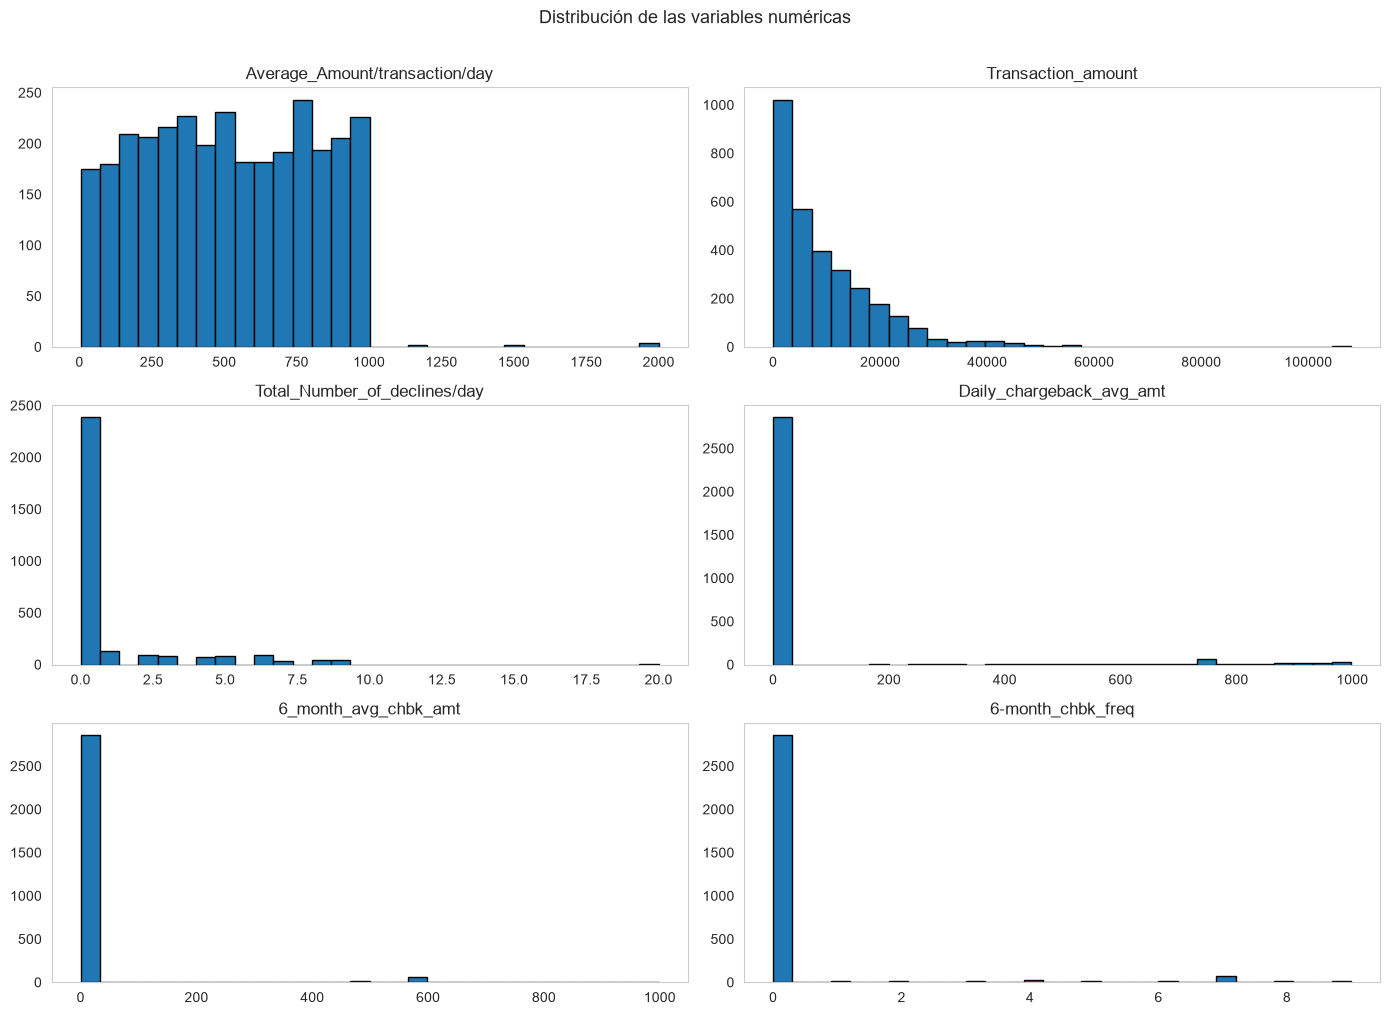

In [113]:
# Distribución de las variables numéricas
num.hist(figsize=(14, 10), bins=30, edgecolor='black', grid=False)
plt.suptitle('Distribución de las variables numéricas', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

El importe promedio diario presenta una distribución aproximadamente simétrica, mientras que las restantes variables están fuertemente sesgadas. El importe de la transacción tiene un máximo de 108000 y una mediana de 6600, lo que indica que unas pocas operaciones de cuantía muy elevada estiran la distribución. Las variables de contracargo y de rechazos, por su parte, se concentran masivamente en el valor cero. Estas asimetrías justifican dos decisiones metodológicas: el cálculo de un coeficiente de correlación alternativo y la transformación de variables antes de aplicar el modelo de detección de anomalías.

### 3.2 Frecuencias para las variables categóricas

In [114]:
# Frecuencias de las variables categóricas
cat = df.select_dtypes(include=['object', 'category', 'bool'])

frames = []
for col in cat.columns:
    vc = cat[col].value_counts(dropna=False)
    frames.append(pd.DataFrame({
        'Variable'  : col,
        'Categoría' : vc.index.astype(str),
        'Frecuencia': vc.values,
        'Porcentaje': (vc.values / len(cat) * 100).round(2),
    }))

tabla_cat = pd.concat(frames, ignore_index=True)
tabla_cat

,Variable,Categoría,Frecuencia,Porcentaje
0,Is_declined,N,3018,98.1500
1,Is_declined,Y,57,1.8500
2,isForeignTransaction,N,2369,77.0400
3,isForeignTransaction,Y,706,22.9600
4,isHighRiskCountry,N,2870,93.3300
5,isHighRiskCountry,Y,205,6.6700
6,isFradulent,N,2627,85.4300
7,isFradulent,Y,448,14.5700


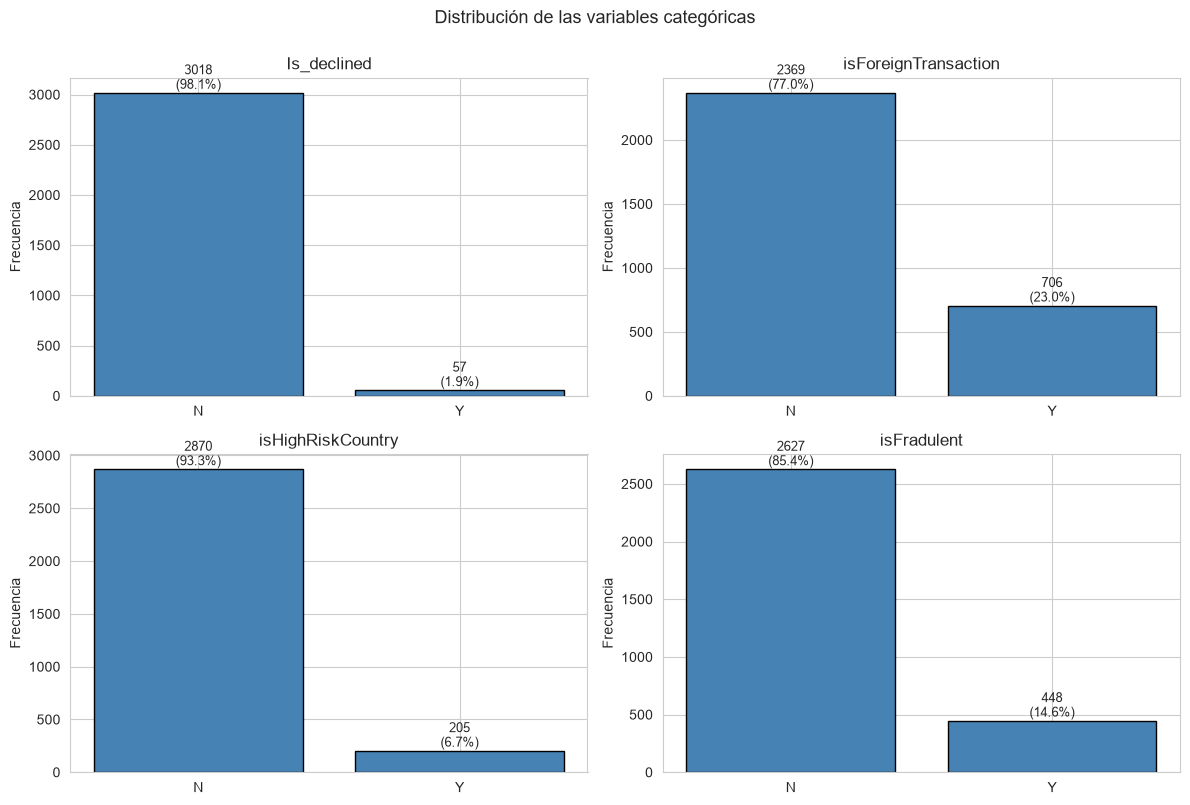

In [115]:
# Visualización de la distribución de las variables categóricas
cols = 2
filas_g = math.ceil(len(cat.columns) / cols)

fig, axes = plt.subplots(filas_g, cols, figsize=(6*cols, 4*filas_g))
axes = axes.flatten()

for i, col in enumerate(cat.columns):
    vc = cat[col].value_counts(dropna=False)
    axes[i].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v, f'{v}\n({v/len(cat)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

for k in range(len(cat.columns), len(axes)):
    axes[k].axis('off')

plt.suptitle('Distribución de las variables categóricas', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

Los fraudes representan el 14,6% de los registros, por lo que la exactitud deja de ser un criterio válido, ya que un sistema que simplemente respondiera «no hay fraude» ante cualquier transacción acertaría el 85,4% de las veces sin haber detectado un solo caso. Por este motivo, la evaluación posterior prioriza el recall y el F1. En escenarios reales de fraude, la clase positiva suele representar menos del 1 % de las operaciones (el conjunto de referencia europeo más utilizado en la literatura contiene un 0,172 % de fraude (Dal Pozzolo et al., 2015)), de modo que el 14,6 % de este archivo constituye un desbalance moderado, dos órdenes de magnitud por encima de lo habitual.

Las cuatro variables dicotómicas, almacenadas en texto, quedarían excluidas de cualquier cálculo numérico. Declararlas explícitamente como binarias las incorpora al análisis y permite su procesamiento por las bibliotecas de modelado.

### 3.3 Matriz de correlaciones

Nota metodológica: Las cuatro variables dicotómicas se codifican previamente como binarias 0/1. Aplicado a variables de este tipo, el coeficiente de Pearson equivale al coeficiente phi, por lo que su interpretacion como medida de asociación sigue siendo válida. Se excluyen `Merchant_id`, por ser un identificador sin significado ordinal, y `Transaction_date`, por carecer de valores.

Se calculan ambos coeficientes: Pearson como referencia principal y Spearman como contraste, dado que varias variables presentan asimetría pronunciada y elevada concentración de ceros, condiciones en las que la asociación lineal puede resultar enganosa.

In [116]:
# Construcción del conjunto de modelado: codificación binaria y nombres legibles
df_model = df.copy()

binarias = ['Is_declined', 'isForeignTransaction', 'isHighRiskCountry', 'isFradulent']
for c in binarias:
    df_model[c] = df_model[c].map({'N': 0, 'Y': 1})

df_model = df_model.rename(columns={
    'Average_Amount/transaction/day': 'Avg_amount_day',
    'Total_Number_of_declines/day'  : 'Declines_day',
    'Daily_chargeback_avg_amt'      : 'Chbk_day_amt',
    '6_month_avg_chbk_amt'          : 'Chbk_6m_amt',
    '6-month_chbk_freq'             : 'Chbk_6m_freq',
})

print('df  -> analisis descriptivo (conserva etiquetas Y/N)')
print('df_model -> analisis cuantitativo y modelado (codificacion numerica)')
df_model.head()

df  -> analisis descriptivo (conserva etiquetas Y/N)
df_model -> analisis cuantitativo y modelado (codificacion numerica)


,Merchant_id,Transaction_date,Avg_amount_day,Transaction_amount,Is_declined,Declines_day,isForeignTransaction,isHighRiskCountry,Chbk_day_amt,Chbk_6m_amt,Chbk_6m_freq,isFradulent
0,3160040998,NaN,100.0000,3000.0000,0,5,1,1,0,0.0000,0,1
1,3160040998,NaN,100.0000,4300.0000,0,5,1,1,0,0.0000,0,1
2,3160041896,NaN,185.5000,4823.0000,1,5,0,0,0,0.0000,0,1
3,3160141996,NaN,185.5000,5008.5000,1,8,0,0,0,0.0000,0,1
4,3160241992,NaN,500.0000,26000.0000,0,0,1,1,800,677.2000,6,1


In [117]:
# Matrices de correlación sobre todas las variables analíticas
corr_vars = (df_model
             .drop(columns=['Merchant_id', 'Transaction_date'], errors='ignore')
             .dropna(axis=1, how='all'))

corr_pearson  = corr_vars.corr(method='pearson')
corr_spearman = corr_vars.corr(method='spearman')

display(Markdown('**Matriz de correlaciones (Pearson)**'))
display(corr_pearson.round(3))

**Matriz de correlaciones (Pearson)**

,Avg_amount_day,Transaction_amount,Is_declined,Declines_day,isForeignTransaction,isHighRiskCountry,Chbk_day_amt,Chbk_6m_amt,Chbk_6m_freq,isFradulent
Avg_amount_day,1.0000,0.5870,0.0810,-0.0100,0.0470,0.0150,0.0600,0.0600,0.0720,0.0240
Transaction_amount,0.5870,1.0000,0.1970,0.2590,0.2770,0.3250,0.2520,0.2600,0.2980,0.5290
Is_declined,0.0810,0.1970,1.0000,0.1160,0.0800,0.1280,0.3940,0.4080,0.4990,0.2710
Declines_day,-0.0100,0.2590,0.1160,1.0000,0.2280,0.2920,0.0950,0.0810,0.0850,0.5320
isForeignTransaction,0.0470,0.2770,0.0800,0.2280,1.0000,0.4900,0.0550,0.0610,0.0770,0.4780
isHighRiskCountry,0.0150,0.3250,0.1280,0.2920,0.4900,1.0000,0.0750,0.0730,0.0980,0.6400
Chbk_day_amt,0.0600,0.2520,0.3940,0.0950,0.0550,0.0750,1.0000,0.9540,0.8850,0.3860
Chbk_6m_amt,0.0600,0.2600,0.4080,0.0810,0.0610,0.0730,0.9540,1.0000,0.8510,0.3760
Chbk_6m_freq,0.0720,0.2980,0.4990,0.0850,0.0770,0.0980,0.8850,0.8510,1.0000,0.4440
isFradulent,0.0240,0.5290,0.2710,0.5320,0.4780,0.6400,0.3860,0.3760,0.4440,1.0000


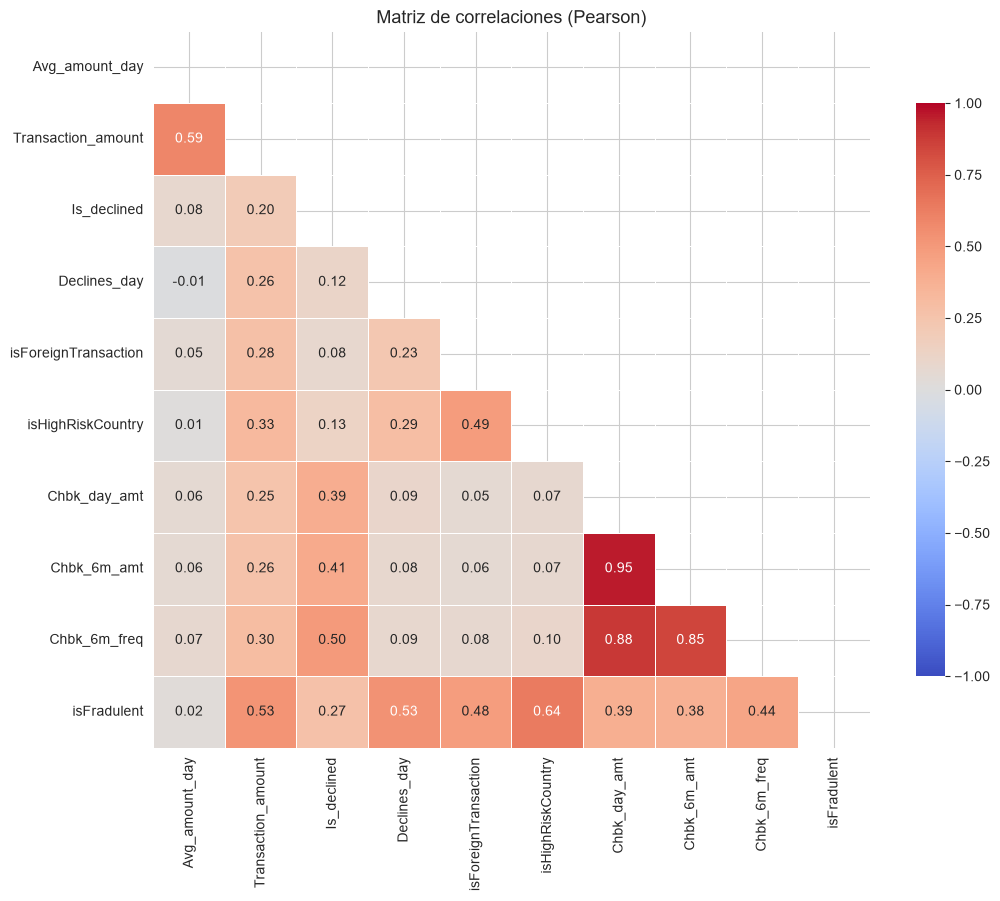

In [118]:
# Mapa de calor de la matriz de correlaciones (Pearson)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlaciones (Pearson)', fontsize=13)
plt.tight_layout()
plt.show()

La lectura de la matriz de correlación con Pearson permite establecer los siguientes puntos, con relación a la variable objetivo:

- La variable que indica la procedencia de un país de alto riesgo presenta la asociación más alta, con un coeficiente de correlación de 0,640. Al realizar un examen detallado, se revela una relación casi determinista: de las 205 transacciones con ese origen, 203 son fraudulentas, lo que representa el 99,0 %. Este dato servirá de base para la reflexión ética del numeral 8.5.
- El número de rechazos diarios (R=0,532) y el importe de la operación (R=0,529) muestran el efecto de los intentos repetidos y de los importes elevados. El importe medio en fraude asciende a 22.855 frente a 7.663 en las transacciones legítimas.
- Las tres variables relacionadas con los contracargos se asocian moderadamente con el fraude (valores entre 0,376 y 0,444), pero entre sí están casi solapadas, lo cual se evidencia al observar que la correlación entre el promedio diario y el semestral alcanza 0,954.
- El importe promedio diario del comercio presenta una correlación de tan solo 0,024 con la variable objetivo, a pesar de tener un valor de 0,587 con el importe de la transacción. Esto implica que esta variable no informa sobre el nivel absoluto del gasto habitual, sino sobre cuánto se desvía de dicho nivel la operación evaluada. 


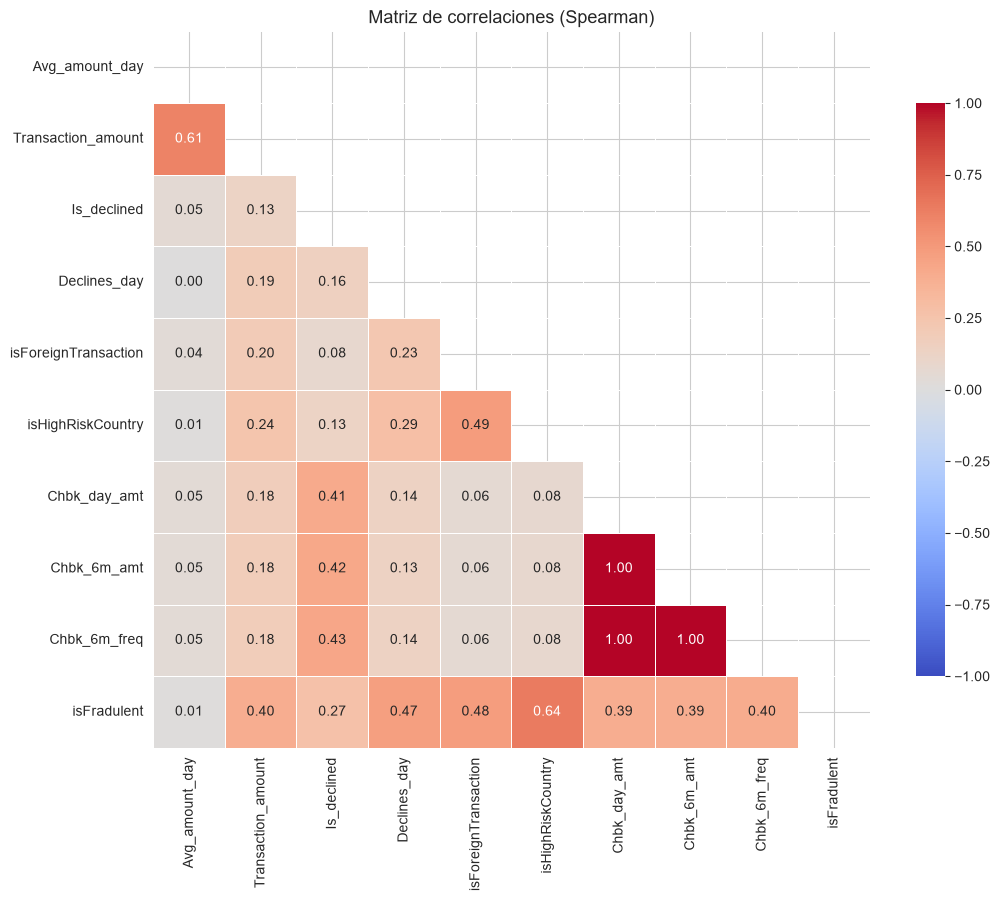

In [119]:
# Mapa de calor de la matriz de correlaciones (Spearman)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlaciones (Spearman)', fontsize=13)
plt.tight_layout()
plt.show()

,Pearson,Spearman
isHighRiskCountry,0.6400,0.6400
Declines_day,0.5320,0.4730
Transaction_amount,0.5290,0.3980
isForeignTransaction,0.4780,0.4780
Chbk_6m_freq,0.4440,0.4010
Chbk_day_amt,0.3860,0.3920
Chbk_6m_amt,0.3760,0.3930
Is_declined,0.2710,0.2710
Avg_amount_day,0.0240,0.0130


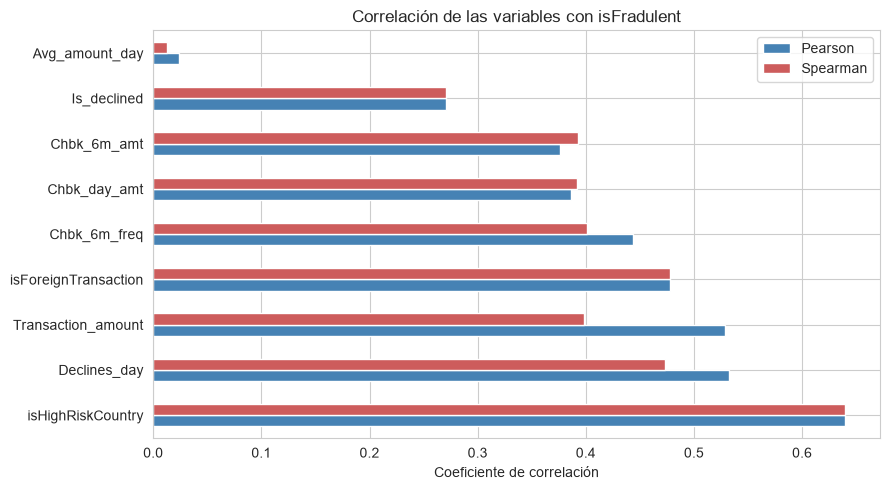

In [120]:
# Correlación de cada variable con el objetivo
rank_corr = pd.DataFrame({
    'Pearson' : corr_pearson['isFradulent'].drop('isFradulent'),
    'Spearman': corr_spearman['isFradulent'].drop('isFradulent'),
}).sort_values('Pearson', ascending=False).round(3)

display(rank_corr)

rank_corr.plot(kind='barh', figsize=(9, 5), color=['steelblue', 'indianred'])
plt.title('Correlación de las variables con isFradulent')
plt.xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.show()

In [121]:
# Contraste dirigido Pearson vs Spearman: solo los pares con discrepancia relevante
sup = np.triu(np.ones(corr_pearson.shape), k=1).astype(bool)

comp = (pd.DataFrame({
            'Pearson' : corr_pearson.where(sup).stack(),
            'Spearman': corr_spearman.where(sup).stack()})
        .assign(Diferencia=lambda d: (d.Spearman - d.Pearson).round(3))
        .query('abs(Diferencia) > 0.05')
        .sort_values('Diferencia', key=abs, ascending=False)
        .round(3))

comp.index.names = ['Variable 1', 'Variable 2']
comp

Pearson  Spearman  Diferencia
Variable 1         Variable 2                                         
Chbk_6m_amt        Chbk_6m_freq           0.8510    0.9980      0.1470
Transaction_amount isFradulent            0.5290    0.3980     -0.1310
                   Chbk_6m_freq           0.2980    0.1820     -0.1150
Chbk_day_amt       Chbk_6m_freq           0.8850    0.9980      0.1130
Transaction_amount isHighRiskCountry      0.3250    0.2440     -0.0820
                   Chbk_6m_amt            0.2600    0.1800     -0.0800
                   Chbk_day_amt           0.2520    0.1780     -0.0740
                   isForeignTransaction   0.2770    0.2030     -0.0740
                   Is_declined            0.1970    0.1300     -0.0670
                   Declines_day           0.2590    0.1930     -0.0670
Is_declined        Chbk_6m_freq           0.4990    0.4330     -0.0660
Declines_day       isFradulent            0.5320    0.4730     -0.0590
                   Chbk_6m_amt            0.0810    0.1350      0.0540
                   Chbk_6m_freq           0.0850    0.1360      0.0510

Al contrastar los dos coeficientes (Pearson vs Spearman) se encuentran dos discrepancias de relevancia. Primero, la asociación entre el importe y el fraude cae de 0,529 a 0,398 al trabajar con rangos; esto indica que el coeficiente lineal está sesgado por unas pocas operaciones de cuantía extrema. Segundo, la redundancia entre las variables de contracargo se intensifica hasta alcanzar 0,998, lo que confirma que los registros se ordenan de manera casi idéntica. Debe notarse que el elevado número de empates (el 92,9% de los registros presenta un contracargo nulo) condiciona parcialmente esta última medida.

### 3.4 Tratamiento de valores faltantes y datos atípicos

In [122]:
# Diagnóstico de completitud: nulos frente a ceros estructurales
diag = pd.DataFrame({
    'Tipo'    : df.dtypes.astype(str),
    'Nulos'   : df.isna().sum(),
    '% nulos' : (df.isna().mean() * 100).round(2),
    'Ceros'   : (df == 0).sum(),
    '% ceros' : ((df == 0).mean() * 100).round(2),
})
diag

,Tipo,Nulos,% nulos,Ceros,% ceros
Merchant_id,int64,0,0.0000,0,0.0000
Transaction_date,float64,3075,100.0000,0,0.0000
Average_Amount/transaction/day,float64,0,0.0000,0,0.0000
Transaction_amount,float64,0,0.0000,91,2.9600
Is_declined,str,0,0.0000,0,0.0000
Total_Number_of_declines/day,int64,0,0.0000,2384,77.5300
isForeignTransaction,str,0,0.0000,0,0.0000
isHighRiskCountry,str,0,0.0000,0,0.0000
Daily_chargeback_avg_amt,int64,0,0.0000,2857,92.9100
6_month_avg_chbk_amt,float64,0,0.0000,2857,92.9100


In [123]:
# Diagnóstico de valores atípicos mediante la regla del rango intercuartílico
num_cols = ['Avg_amount_day', 'Transaction_amount', 'Declines_day',
            'Chbk_day_amt', 'Chbk_6m_amt', 'Chbk_6m_freq']

filas_iqr = []
for c in num_cols:
    q1, q3 = df_model[c].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df_model[c] < lo) | (df_model[c] > hi)).sum()
    filas_iqr.append({'Variable': c, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                      'Limite sup.': hi, 'Atipicos': n_out,
                      '%': round(n_out/len(df_model)*100, 1)})

pd.DataFrame(filas_iqr).set_index('Variable')

,Q1,Q3,IQR,Limite sup.,Atipicos,%
Variable,,,,,,
Avg_amount_day,269.7880,765.2728,495.4848,1508.4999,4,0.1000
Transaction_amount,2408.7811,14422.5689,12013.7878,32443.2506,113,3.7000
Declines_day,0.0000,0.0000,0.0000,0.0000,691,22.5000
Chbk_day_amt,0.0000,0.0000,0.0000,0.0000,218,7.1000
Chbk_6m_amt,0.0000,0.0000,0.0000,0.0000,218,7.1000
Chbk_6m_freq,0.0000,0.0000,0.0000,0.0000,218,7.1000


- El diagnóstico de la completitud de los datos permitió identificar un único caso de valores ausentes: la variable de fecha está vacía en la totalidad de los registros. Por lo tanto, se tomó la decisión de eliminarla del dataset. 
- Las tres variables de contracargo presentan un 92,9% de ceros y la de rechazos un 77,5%, pero estos no son datos ausentes. Estos valores representan una situación normal de un comercio sin incidencias registradas.
- No se eliminan estos «valores atípicos» por considerarse que aportan información y no constituyen errores en el dataset.

In [124]:
# Aplicación de la decisión y sincronización de ambos DataFrames
df       = df.drop(columns=['Transaction_date'], errors='ignore')
df_model = df_model.drop(columns=['Transaction_date'], errors='ignore')

print(f'Registros conservados : {len(df)} de {len(df_raw)} (100 %)')
print(f'Columnas en df        : {df.shape[1]}')
print(f'Columnas en df_model  : {df_model.shape[1]}')

# Verificaciones de integridad
assert df_model.isna().sum().sum() == 0, 'Quedan valores nulos en df_model'
assert df_model.select_dtypes('object').empty, 'Quedan columnas no numericas en df_model'
print('\nVerificaciones de integridad superadas.')

Registros conservados : 3075 de 3075 (100 %)
Columnas en df        : 11
Columnas en df_model  : 11

Verificaciones de integridad superadas.


### 3.5 Ingeniería de variables: el ratio de desviación

El análisis de correlaciones evidenció que `Avg_amount_day` carece de asociación con el fraude por si sola (r = 0,024), pese a correlacionar 0,587 con el importe de la transacción. La información relevante no reside en el nivel absoluto del gasto habitual del comercio, sino en cuánto se desvia la transacción evaluada de ese patrón.

Se construye en consecuencia la variable `ratio_amount`, interpretable como número de veces que la transacción supera el comportamiento habitual del comercio.

*Esta variable podría no ser utilizada en análisis posteriores pero se mantiene en el Notebook dada la importancia interpretativa de los datos.*

In [125]:
# Variable derivada: desviación del importe respecto al patrón habitual del comercio
print('Divisores nulos:', (df_model['Avg_amount_day'] == 0).sum(),
      '| minimo observado:', round(df_model['Avg_amount_day'].min(), 2))

df_model['ratio_amount'] = df_model['Transaction_amount'] / df_model['Avg_amount_day']

df_model.groupby('isFradulent')['ratio_amount'].describe().round(2)

Divisores nulos: 0 | minimo observado: 4.01


,count,mean,std,min,25%,50%,75%,max
isFradulent,,,,,,,,
0,2627.0000,14.9000,9.0500,0.0000,7.0000,15.0000,23.0000,30.0000
1,448.0000,42.8700,10.6500,25.0000,34.0000,43.0000,52.0000,60.0000


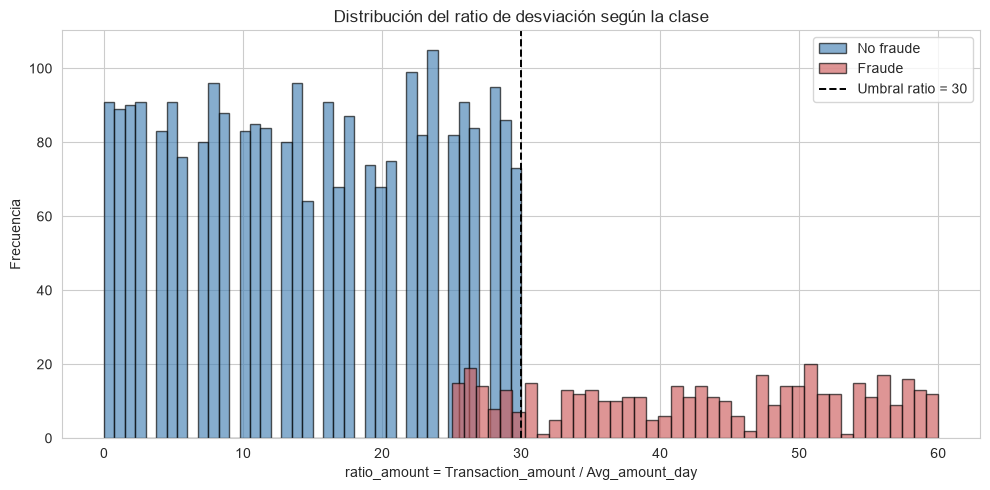

Correlación con isFradulent -- Pearson: 0.728 | Spearman: 0.588


In [126]:
# Distribución del ratio por clase
plt.figure(figsize=(10, 5))
for k, etiqueta, color in [(0, 'No fraude', 'steelblue'), (1, 'Fraude', 'indianred')]:
    plt.hist(df_model.loc[df_model.isFradulent == k, 'ratio_amount'],
             bins=40, alpha=.65, label=etiqueta, color=color, edgecolor='black')
plt.axvline(30, ls='--', c='black', lw=1.4, label='Umbral ratio = 30')
plt.xlabel('ratio_amount = Transaction_amount / Avg_amount_day')
plt.ylabel('Frecuencia')
plt.title('Distribución del ratio de desviación según la clase')
plt.legend()
plt.tight_layout()
plt.show()

print('Correlación con isFradulent -- '
      f'Pearson: {df_model.ratio_amount.corr(df_model.isFradulent):.3f} | '
      f'Spearman: {df_model.ratio_amount.corr(df_model.isFradulent, method="spearman"):.3f}')

In [127]:
# Verificación del hallazgo estructural
desvio = (df_model.ratio_amount - df_model.ratio_amount.round()).abs().max()
print(f'Desviación máxima respecto al entero más próximo: {desvio:.2e}')

# Distribución por tramos
tramos = pd.cut(df_model.ratio_amount.round(), [-1, 20, 30, 60],
                labels=['<= 20', '21 - 30', '> 30'])
tabla_tramos = pd.crosstab(tramos, df_model.isFradulent, margins=True)
tabla_tramos.columns = ['No fraude', 'Fraude', 'Total']
display(tabla_tramos)

# Regla de umbral trivial (linea base superior)
pred_regla_full = (df_model.ratio_amount > 30).astype(int)
vp = ((pred_regla_full == 1) & (df_model.isFradulent == 1)).sum()
fp = ((pred_regla_full == 1) & (df_model.isFradulent == 0)).sum()
fn = ((pred_regla_full == 0) & (df_model.isFradulent == 1)).sum()

print('\nRegla "ratio > 30 => fraude" (sobre el conjunto completo)')
print(f'  Exactitud : {(pred_regla_full == df_model.isFradulent).mean():.4f}')
print(f'  Precision : {vp/(vp+fp):.4f}')
print(f'  Recall    : {vp/(vp+fn):.4f}')

Desviación máxima respecto al entero más próximo: 2.41e-08


,No fraude,Fraude,Total
ratio_amount,,,
<= 20,1755,0,1755
21 - 30,872,76,948
> 30,0,372,372
All,2627,448,3075



Regla "ratio > 30 => fraude" (sobre el conjunto completo)
  Exactitud : 0.9655
  Precision : 0.9171
  Recall    : 0.8393


El importe de cada transacción resulta ser un **múltiplo entero exacto** del importe promedio diario del comercio: la desviación máxima respecto al entero mas próximo es del orden de 10 elevado a -8, atribuible a redondeo en coma flotante.

El ratio toma valores enteros entre 0 y 60, y las clases se separan de forma casi determínista:

| Rango del ratio | No fraude | Fraude | % fraude |
|---|---|---|---|
| <= 20 | 1.755 | **0** | 0 % |
| 21 - 30 | 872 | 76 | 8,0 % |
| > 30 | **0** | 372 | **100 %** |

La variable `ratio_amount` se **excluye del conjunto de entrenamiento** de los modelos supervisados, con el fin de preservar una comparación > informativa entre Naive Bayes, random forest, boosting y SVM. Su efecto se cuantifíca > mediante un experimento complementario en la Seccion 16.

## 4. Agrupamiento con K-means

> **Criterio 2 de la guía (10%)** - *"Aplica e interpreta el agrupamiento de manera coherente con el caso."*

In [128]:
# Preparación: se excluyen la etiqueta (no supervisado), el identificador y la variable derivada
X_clu = df_model.drop(columns=['isFradulent', 'Merchant_id', 'ratio_amount'],
                      errors='ignore')

escalador_clu = StandardScaler()
X_scaled = escalador_clu.fit_transform(X_clu)

print(f'Variables utilizadas ({X_clu.shape[1]}): {list(X_clu.columns)}')

Variables utilizadas (9): ['Avg_amount_day', 'Transaction_amount', 'Is_declined', 'Declines_day', 'isForeignTransaction', 'isHighRiskCountry', 'Chbk_day_amt', 'Chbk_6m_amt', 'Chbk_6m_freq']


El escala hecho se justifica en que K-means asigna cada observación al centroide mas próximo según la distancia euclidea, medida sensible a la escala. En este conjunto, `Transaction_amount` alcanza 108.000 mientras `Chbk_6m_freq` no supera 9: sin estandarizar, el importe absorbería prácticamente toda la distancia y las restantes variables no influirían en la formación de los grupos. Se aplica `StandardScaler` (media 0, desviacion 1).

Se excluye `isFradulent` porque el agrupamiento es no supervisado: la etiqueta se reserva exclusivamente para **evaluar a posteriori** la calidad de los grupos obtenidos.

,Inercia,Silueta,Davies-Bouldin
k,,,
2,18611.0000,0.6610,0.9380
3,14635.0000,0.5560,1.0280
4,12261.0000,0.3270,1.1200
5,9952.0000,0.3420,1.0670
6,8176.0000,0.4060,0.9610
7,7009.0000,0.4370,0.9130
8,6623.0000,0.4310,1.1660


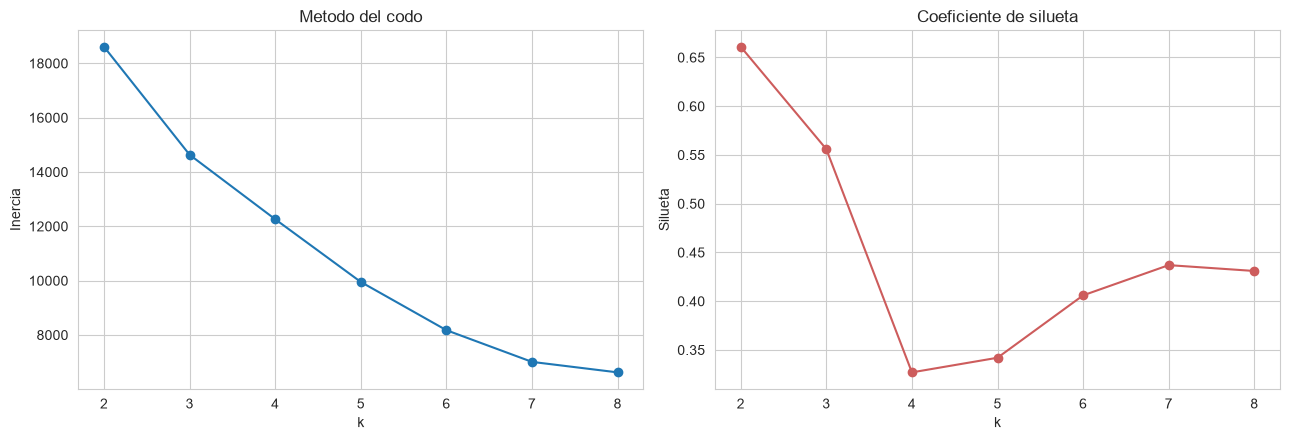

In [129]:
# Selección del número de grupos
filas_k = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X_scaled)
    filas_k.append({
        'k'             : k,
        'Inercia'       : round(km.inertia_, 0),
        'Silueta'       : round(silhouette_score(X_scaled, km.labels_), 3),
        'Davies-Bouldin': round(davies_bouldin_score(X_scaled, km.labels_), 3),
    })

metricas_k = pd.DataFrame(filas_k).set_index('k')
display(metricas_k)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(metricas_k.index, metricas_k.Inercia, 'o-')
ax[0].set_title('Metodo del codo'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia')
ax[1].plot(metricas_k.index, metricas_k.Silueta, 'o-', color='indianred')
ax[1].set_title('Coeficiente de silueta'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silueta')
plt.tight_layout()
plt.show()

Los índices internos favorecen **k = 2** (silueta 0,661; Davies-Bouldin 0,938), seguido de **k = 3** (0,556; 1,028). El método del codo no muestra un punto de inflexion nítido.

### 4.1 Solución con tres grupos

In [130]:
# Solución con k = 3
km3 = KMeans(n_clusters=3, n_init=10, random_state=SEMILLA).fit(X_scaled)
df_model['cluster_k3'] = km3.labels_

cent3 = pd.DataFrame(escalador_clu.inverse_transform(km3.cluster_centers_),
                     columns=X_clu.columns)
cent3['n']        = pd.Series(km3.labels_).value_counts().sort_index()
cent3['% fraude'] = (df_model.groupby('cluster_k3').isFradulent.mean() * 100).round(1)

display(Markdown('**Centroides en unidades originales (k = 3)**'))
display(cent3.round(2))
display(pd.crosstab(df_model.cluster_k3, df_model.isFradulent, margins=True))

**Centroides en unidades originales (k = 3)**

,Avg_amount_day,Transaction_amount,Is_declined,Declines_day,isForeignTransaction,isHighRiskCountry,Chbk_day_amt,Chbk_6m_amt,Chbk_6m_freq,n,% fraude
0,507.3600,7864.5300,0.0000,0.5600,0.1600,0.0000,1.8200,1.0200,0.0100,2630,2.8000
1,586.0900,19925.0600,0.2400,1.6700,0.3200,0.1400,806.2200,585.2900,5.7200,205,67.3000
2,538.2900,23339.9200,0.0100,4.6900,0.9500,0.7400,5.5900,1.6900,0.0300,240,98.3000


isFradulent,0,1,All
cluster_k3,,,
0,2556,74,2630
1,67,138,205
2,4,236,240
All,2627,448,3075


### Comentarios sobre la Figura 4 (k = 3)

Estos resultados permiten deducir:

- En el grupo 0 se tienen operaciones normales con importes moderados (7865 de media), ausencia práctica de rechazos y contracargos, y actividad mayoritariamente nacional.
- En el grupo 1 se concentran los comercios con historial de contracargos, con un promedio diario de 806 y 5,7 contracargos por semestre. Presenta la mayor tasa de rechazo directo (24%) y un perfil de riesgo acumulado.
- En el grupo 2 se registran operaciones internacionales (95%), con países de alto riesgo (74%), con más rechazos diarios (4,7) e importes elevados (23340), pero sin historial de contracargos.


### 4.2 Solución con dos grupos

In [131]:
# Solución con k = 2
km2 = KMeans(n_clusters=2, n_init=10, random_state=SEMILLA).fit(X_scaled)
df_model['cluster_k2'] = km2.labels_

cent2 = pd.DataFrame(escalador_clu.inverse_transform(km2.cluster_centers_),
                     columns=X_clu.columns)
cent2['n']        = pd.Series(km2.labels_).value_counts().sort_index()
cent2['% fraude'] = (df_model.groupby('cluster_k2').isFradulent.mean() * 100).round(1)

display(Markdown('**Centroides en unidades originales (k = 2)**'))
display(cent2.round(2))
display(pd.crosstab(df_model.cluster_k2, df_model.isFradulent, margins=True))

display(Markdown('**Correspondencia entre ambas soluciones**'))
display(pd.crosstab(df_model.cluster_k3, df_model.cluster_k2))

**Centroides en unidades originales (k = 2)**

,Avg_amount_day,Transaction_amount,Is_declined,Declines_day,isForeignTransaction,isHighRiskCountry,Chbk_day_amt,Chbk_6m_amt,Chbk_6m_freq,n,% fraude
0,586.1500,19908.6400,0.2400,1.6600,0.3300,0.1500,805.0500,583.4800,5.7100,206,67.5000
1,509.9200,9156.0600,0.0000,0.9100,0.2200,0.0600,1.9400,1.0000,0.0100,2869,10.8000


isFradulent,0,1,All
cluster_k2,,,
0,67,139,206
1,2560,309,2869
All,2627,448,3075


**Correspondencia entre ambas soluciones**

cluster_k2,0,1
cluster_k3,,
0,0,2630
1,204,1
2,2,238


La partición en dos grupos reproduce únicamente la primera separación: aisla el grupo de comercios con historial de contracargos (n = 206; 67,5 % de fraude) y agrupa **todo lo demás** en un único conglomerado de 2.869 registros.

## 5. Deteccion de anomalías

> **Criterio 3 de la rúbrica (10%)** - *"Implementa e interpreta correctamente la detección de anomalías."*

In [132]:
# Paso 1: partición según el procedimiento del Tema 11
rng   = np.random.RandomState(SEMILLA)
y_all = df_model['isFradulent'].values

norm = np.where(y_all == 0)[0]; rng.shuffle(norm)
anom = np.where(y_all == 1)[0]; rng.shuffle(anom)
n_norm, n_anom = len(norm), len(anom)

idx_train = norm[:int(.6*n_norm)]                                              # 60 % normales
idx_cv    = np.concatenate([norm[int(.6*n_norm):int(.8*n_norm)], anom[:n_anom//2]])
idx_test  = np.concatenate([norm[int(.8*n_norm):],               anom[n_anom//2:]])

print(f'Entrenamiento : {len(idx_train):4d}  (solo ejemplos normales)')
print(f'Validacion    : {len(idx_cv):4d}  ({(y_all[idx_cv]==1).sum()} anomalos)')
print(f'Test          : {len(idx_test):4d}  ({(y_all[idx_test]==1).sum()} anomalos)')

Entrenamiento : 1576  (solo ejemplos normales)
Validacion    :  749  (224 anomalos)
Test          :  750  (224 anomalos)


In [177]:
# Paso 2: selección y transformación de variables
V_gauss = ['Avg_amount_day', 'Transaction_amount', 'Declines_day', 'Chbk_6m_freq']

X_gauss = df_model[V_gauss].copy()
asim_orig = X_gauss.skew().round(2)

# Transformaciones para aproximar la normalidad (supuesto del modelo)
X_gauss['Transaction_amount'] = np.sqrt(X_gauss['Transaction_amount'])
X_gauss['Declines_day']       = np.log1p(X_gauss['Declines_day'])
X_gauss['Chbk_6m_freq']       = np.log1p(X_gauss['Chbk_6m_freq'])

pd.DataFrame({'Asimetría original': asim_orig,
              'Asimetría transformada': X_gauss.skew().round(2)})

,Asimetría original,Asimetría transformada
Avg_amount_day,0.1800,0.1800
Transaction_amount,2.1100,0.4800
Declines_day,2.6900,1.7500
Chbk_6m_freq,4.0500,3.6400


Se seleccionan cuatro variables continuas o de conteo. Se **excluyen las dicotómicas** porque
el modelo gaussiano carece de sentido sobre variables de dos valores, y se excluyen dos de las
tres de contracargo por la redundancia detectada en la Sección 5.

El modelo asume distribución gaussiana, supuesto que los datos originales no cumplen
(asimetróa de 2,11 a 4,05). Se aplican transformaciones de raiz cuadrada y logarítmica para
aproximar la normalidad. La corrección es **parcial** en las variables con exceso de ceros,
limitacion que se documenta como tal.

In [134]:
# Paso 3: ajuste de parámetros SOLO sobre ejemplos normales
mu     = X_gauss.values[idx_train].mean(axis=0)
sigma2 = X_gauss.values[idx_train].var(axis=0)

pd.DataFrame({'mu': mu.round(3), 'sigma^2': sigma2.round(3)}, index=V_gauss)

,mu,sigma^2
Avg_amount_day,515.4320,82211.5610
Transaction_amount,76.6480,1727.1300
Declines_day,0.2020,0.2610
Chbk_6m_freq,0.0420,0.0670


In [135]:
# Paso 4: probabilidad gaussiana conjunta
def p_gaussiana(M, mu, sigma2):
    """Densidad gaussiana conjunta bajo el supuesto de independencia entre variables."""
    return np.prod(1/np.sqrt(2*np.pi*sigma2) * np.exp(-(M - mu)**2 / (2*sigma2)), axis=1)

p_cv   = p_gaussiana(X_gauss.values[idx_cv],   mu, sigma2)
p_test = p_gaussiana(X_gauss.values[idx_test], mu, sigma2)

# Paso 5: busqueda de epsilon maximizando F1 sobre validacion
mejor_f1, mejor_eps = 0, None
for eps in np.quantile(p_cv, np.linspace(0.001, 0.5, 600)):
    f1 = f1_score(y_all[idx_cv], (p_cv < eps).astype(int))
    if f1 > mejor_f1:
        mejor_f1, mejor_eps = f1, eps

print(f'epsilon optimo = {mejor_eps:.3e}   |   F1 en validacion = {mejor_f1:.3f}')

epsilon optimo = 5.229e-07   |   F1 en validacion = 0.792


In [136]:
# Función auxiliar reutilizable: matriz de confusión etiquetada + metricas
def evaluar(y_real, y_pred, titulo='Modelo'):
    """Presenta la matriz de confusión como tabla y devuelve (matriz, metricas)."""
    mc = pd.DataFrame(
        confusion_matrix(y_real, y_pred),
        index=pd.Index(['Real: Normal', 'Real: Fraude'], name=titulo),
        columns=pd.Index(['Pred: Normal', 'Pred: Fraude'], name=''))

    tn, fp, fn, vp = confusion_matrix(y_real, y_pred).ravel()
    met = pd.DataFrame({'Valor': [
        round(precision_score(y_real, y_pred), 4),
        round(recall_score(y_real, y_pred), 4),
        round(f1_score(y_real, y_pred), 4),
        round((vp + tn) / len(y_real), 4),
        int(fn), int(fp)]},
        index=['Precisión', 'Recall (sensibilidad)', 'F1-score',
               'Exactitud', 'Falsos negativos', 'Falsos positivos'])

    display(Markdown(f'**Matriz de confusión - {titulo}**'))
    display(mc)
    display(met)
    return mc, met

In [137]:
# Paso 6: evaluacion del modelo gaussiano sobre test independiente
pred_g = (p_test < mejor_eps).astype(int)
mc_gauss, met_gauss = evaluar(y_all[idx_test], pred_g, 'Modelo gaussiano (Tema 11)')

**Matriz de confusión - Modelo gaussiano (Tema 11)**

,Pred: Normal,Pred: Fraude
Modelo gaussiano (Tema 11),,
Real: Normal,466,60
Real: Fraude,34,190


,Valor
Precisión,0.7600
Recall (sensibilidad),0.8482
F1-score,0.8017
Exactitud,0.8747
Falsos negativos,34.0000
Falsos positivos,60.0000


### Contraste con Isolation Forest

**Fundamento.** *Isolation Forest* construye árboles con particiones aleatorias del espacio de
variables. La intuición es que una observación anomala, al estar aislada del resto, requiere
**menos cortes** para quedar separada. La puntuación de anomalía se deriva de la longitud
media del camino hasta aislar cada observación.

A diferencia del modelo gaussiano, **no impone ninguna forma distribucional** ni supone
independencia entre variables. Se ajusta con el mismo protocolo -entrenamiento sobre ejemplos
normales, umbral calibrado en validación por F1- para que la comparación sea legítima.

In [138]:
# Paso 7: Isolation Forest bajo el mismo protocolo
X_iso = df_model.drop(columns=['isFradulent', 'Merchant_id', 'ratio_amount',
                               'cluster_k3', 'cluster_k2'], errors='ignore')

escalador_iso = StandardScaler().fit(X_iso.values[idx_train])
X_iso_s = escalador_iso.transform(X_iso.values)

iso = IsolationForest(n_estimators=200, contamination=0.15,
                      random_state=SEMILLA).fit(X_iso_s[idx_train])

s_cv = -iso.score_samples(X_iso_s[idx_cv])     # mayor valor = mas anomalo
s_te = -iso.score_samples(X_iso_s[idx_test])

mejor_f1_iso, umbral_iso = 0, None
for t in np.quantile(s_cv, np.linspace(0.5, 0.999, 500)):
    f1 = f1_score(y_all[idx_cv], (s_cv > t).astype(int))
    if f1 > mejor_f1_iso:
        mejor_f1_iso, umbral_iso = f1, t

print(f'Umbral calibrado = {umbral_iso:.4f}   |   F1 en validacion = {mejor_f1_iso:.3f}')

pred_i = (s_te > umbral_iso).astype(int)
mc_iso, met_iso = evaluar(y_all[idx_test], pred_i, 'Isolation Forest')

Umbral calibrado = 0.5262   |   F1 en validacion = 0.890


**Matriz de confusión - Isolation Forest**

,Pred: Normal,Pred: Fraude
Isolation Forest,,
Real: Normal,465,61
Real: Fraude,6,218


,Valor
Precisión,0.7814
Recall (sensibilidad),0.9732
F1-score,0.8668
Exactitud,0.9107
Falsos negativos,6.0000
Falsos positivos,61.0000


In [139]:
# Comparacion de ambos métodos
comparacion_anom = pd.concat(
    [met_gauss.rename(columns={'Valor': 'Gaussiano (Tema 11)'}),
     met_iso.rename(columns={'Valor': 'Isolation Forest'})], axis=1)
comparacion_anom['Diferencia'] = (comparacion_anom['Isolation Forest'] -
                                  comparacion_anom['Gaussiano (Tema 11)']).round(4)
comparacion_anom

,Gaussiano (Tema 11),Isolation Forest,Diferencia
Precisión,0.7600,0.7814,0.0214
Recall (sensibilidad),0.8482,0.9732,0.1250
F1-score,0.8017,0.8668,0.0651
Exactitud,0.8747,0.9107,0.0360
Falsos negativos,34.0000,6.0000,-28.0000
Falsos positivos,60.0000,61.0000,1.0000


Los dos métodos identifican el fraude con alto rendimiento sin utilizar la etiqueta correspondiente durante el entrenamiento. Isolation Forest resulta claramente superior en recall, dejando por fuera únicamente 6 fraudes de 224, frente a los 34 del modelo gaussiano. Esto se explica desde los supuestos que están asociados a cada método: mientras que el estimador gaussiano asume independencia entre variables y una distribución normal (condiciones que este conjunto no satisface), Isolation Forest se basa en cortes aleatorios, sin imponer ninguna distribución, y captura interacciones entre variables.

<div style="text-align:center">

## *PARTE 2: Regresión, clasificación, interpretabilidad, boosting, SVM y MLOps*

</div>

## 6. Protocolo experimental común

Sección transversal que sostiene los Criterios 4 a 8. El enunciado exige comparar los modelos **bajo la misma partición y preprocesamiento**, de modo que las diferencias observadas sean atribuibles al algoritmo y no a variaciones en los datos de evaluación.

Se adopta el procedimiento **hold-out** descrito en el Tema 1, con división 80/20 estratificada.

In [140]:
# Definición del conjunto de modelado
EXCLUIR = ['isFradulent',    # variable objetivo
           'Merchant_id',    # identificador, no predictor
           'ratio_amount',   # decision de diseno (Seccion 7)
           'cluster_k3',     # derivada del agrupamiento no supervisado
           'cluster_k2']

X = df_model.drop(columns=EXCLUIR, errors='ignore')
Y = df_model['isFradulent']

print(f'Predictores ({X.shape[1]}):')
for c in X.columns:
    print(f'  - {c}')

Predictores (9):
  - Avg_amount_day
  - Transaction_amount
  - Is_declined
  - Declines_day
  - isForeignTransaction
  - isHighRiskCountry
  - Chbk_day_amt
  - Chbk_6m_amt
  - Chbk_6m_freq


In [178]:
# Partición hold-out estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, stratify=Y, random_state=SEMILLA)

pd.DataFrame({
    'Registros': [len(y_train), len(y_test)],
    'Fraude'   : [y_train.sum(), y_test.sum()],
    '% fraude' : [round(y_train.mean()*100, 2), round(y_test.mean()*100, 2)],
}, index=['Entrenamiento', 'Test'])

,Registros,Fraude,% fraude
Entrenamiento,2460,358,14.5500
Test,615,90,14.6300


In [142]:
# Escalado sin fuga de información: ajustado SOLO con el conjunto de entrenamiento
escalador = StandardScaler().fit(X_train)

X_train_s = pd.DataFrame(escalador.transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(escalador.transform(X_test),  columns=X.columns, index=X_test.index)

print(f'Media máxima en train (debe ser ~0): {X_train_s.mean().abs().max():.6f}')
print(f'Media máxima en test  (sera !=0)   : {X_test_s.mean().abs().max():.4f}')

Media máxima en train (debe ser ~0): 0.000000
Media máxima en test  (sera !=0)   : 0.0566


El escalado se aplica **únicamente con el conjunto de entrenamiento**. Si se cálcula la media y la desviación típica sobre la totalidad de los datos constituiría una **fuga de información** (*data leakage*): el modelo incorporaría estadísticos del conjunto sobre el que después se evalua, produciendo métricas optimistas no reproducibles en producción. Que la media del conjunto de test no sea exactamente cero es el comportamiento correcto y esperado.

Los datos escalados se emplean en los modelos **sensibles a la escala** (SVM, Naive Bayes gaussiano); los basados en arboles operan sobre las variables originales, ya que sus particiones son invariantes a transformaciones monótonas.

In [143]:
# Diagnostico del desbalance de clases
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Proporcion negativos/positivos en entrenamiento: {ratio_desbalance:.2f} : 1')

Proporcion negativos/positivos en entrenamiento: 5.87 : 1


**Tratamiento del desbalance:**

Reponderación de clases mediante `class_weight='balanced'` en los modelos que lo admiten, y `sample_weight` equivalente en los que no. Este mecanísmo incrementa el coste de los errores sobre la clase minoritaria durante el entrenamiento, sin alterar los datos.

**Métricas de evaluación (Tema 3)**

| Métrica | Definición | Interpretación en este caso |
|---|---|---|
| **Precisión** | VP / (VP + FP) | De las transacciones senaladas como fraude, cuantas lo eran. Su reverso es la fricción con clientes legitimos. |
| **Recall** | VP / (VP + FN) | De los fraudes existentes, cuantos se detectaron. **Metrica prioritaria.** |
| **F1-score** | Media armónica de ambas | Métrica de compromiso, robusta ante el desbalance. |
| **ROC-AUC** | Área bajo la curva ROC | Capacidad de ordenación entre clases, independiente del umbral. |
| **PR-AUC** | Área bajo precisión-recall | Más informativa cuando la clase positiva es minoritaria. |
| **Tiempo** | Segundos de entrenamiento | Exigido por el enunciado para la comparación de coste computacional. |

La **exactitud** se reporta solo como referencia: un clasificador que nunca prediga fraude
alcanzaría el 85,4 %.

In [144]:
# Función unificada de entrenamiento y evaluación
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena, cronometra y evalua un clasificador binario. Devuelve (fila, modelo, probabilidades)."""
    t0 = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    t_entrenamiento = time.perf_counter() - t0

    y_pred = modelo.predict(X_te)
    y_prob = (modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, 'predict_proba')
              else modelo.decision_function(X_te))

    tn, fp, fn, vp = confusion_matrix(y_te, y_pred).ravel()

    return {
        'Modelo'    : nombre,
        'Precision' : round(precision_score(y_te, y_pred), 4),
        'Recall'    : round(recall_score(y_te, y_pred), 4),
        'F1'        : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_te, y_prob), 4),
        'PR-AUC'    : round(average_precision_score(y_te, y_prob), 4),
        'Exactitud' : round(accuracy_score(y_te, y_pred), 4),
        'FN'        : int(fn),
        'FP'        : int(fp),
        'Tiempo (s)': round(t_entrenamiento, 3),
    }, modelo, y_prob


# Acumulador de la tabla comparativa final.
# IMPORTANTE: se reinicia aqui para evitar duplicados si la celda se ejecuta mas de una vez.
RESULTADOS = []
print('Función de evaluación definida. Acumulador RESULTADOS inicializado.')

Función de evaluación definida. Acumulador RESULTADOS inicializado.


In [145]:
# Líneas base de referencia
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print('Referencia INFERIOR - clase mayoritaria:')
print(f'  Exactitud: {accuracy_score(y_test, dummy.predict(X_test)):.4f} | Recall: 0.0000')

ratio_test = df_model.loc[X_test.index, 'ratio_amount']
pred_regla = (ratio_test > 30).astype(int)
print('\nReferencia SUPERIOR - regla "ratio > 30" (Seccion 7):')
print(f'  Precisión: {precision_score(y_test, pred_regla):.4f} | '
      f'Recall: {recall_score(y_test, pred_regla):.4f} | '
      f'F1: {f1_score(y_test, pred_regla):.4f}')

# Esquema de validacion cruzada, aplicado UNICAMENTE sobre entrenamiento
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
print(f'\nValidación cruzada estratificada: {cv.get_n_splits()} particiones (solo sobre train).')

Referencia INFERIOR - clase mayoritaria:
  Exactitud: 0.8537 | Recall: 0.0000

Referencia SUPERIOR - regla "ratio > 30" (Seccion 7):
  Precisión: 0.9080 | Recall: 0.8778 | F1: 0.8927

Validación cruzada estratificada: 5 particiones (solo sobre train).


Se establecen dos referencias contra las cuales contrastar los modelos:

- **Inferior**: clasificador de clase mayoritaria, con 85,4 % de exactitud y recall nulo. Ilustra por que la exactitud es enganosa bajo desbalance.
- **Superior**: la regla de umbral `ratio_amount > 30` identificada en la Seccion 7, evaluada sobre el mismo conjunto de test. Constituye el listón real que los modelos deben superar para justificar su complejidad.

**Nota.** La selección de hiperparámetros se realiza mediante validación cruzada estratificada de 5 particiones **sobre el conjunto de entrenamiento**. El conjunto de test permanece intacto hasta la evaluación final, garantizando una estimación no sesgada del desempeñoo sobre datos no vistos.

## 7. Laboratorio de regresión

> **Criterio 4 de la rúbrica (10%)** - *"Desarrolla y evalúa correctamente el laboratorio de regresión."*


Este laboratorio requiere una **partición propia**, distinta de la de la Sección 10, ya que el objetivo es continuo y no procede la estratificación por clase. Se conserva la proporción 80/20 y la misma semilla.

In [146]:
# Partición propia para el problema de regresión
y_reg = df_model['Transaction_amount']
X_reg = df_model.drop(columns=['Transaction_amount', 'Merchant_id', 'ratio_amount',
                               'cluster_k3', 'cluster_k2'], errors='ignore')

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEMILLA)

print(f'Predictores ({X_reg.shape[1]}): {list(X_reg.columns)}')
print(f'Entrenamiento: {len(yr_train)} | Test: {len(yr_test)}')

Predictores (9): ['Avg_amount_day', 'Is_declined', 'Declines_day', 'isForeignTransaction', 'isHighRiskCountry', 'Chbk_day_amt', 'Chbk_6m_amt', 'Chbk_6m_freq', 'isFradulent']
Entrenamiento: 2460 | Test: 615


Se excluye `ratio_amount` conforme a la decisión de diseno de la Seccion 7; su inclusión
constituiria ademas una **fuga directa**, al construirse como cociente en el que interviene la
propia variable respuesta.

In [147]:
# Función auxiliar de evaluación para regresión
def evaluar_regresion(nombre, modelo, Xtr, ytr, Xte, yte):
    modelo.fit(Xtr, ytr)
    pred = modelo.predict(Xte)
    return {
        'Modelo'  : nombre,
        'MAE'     : round(mean_absolute_error(yte, pred), 1),
        'RMSE'    : round(mean_squared_error(yte, pred)**0.5, 1),
        'R2'      : round(r2_score(yte, pred), 4),
        'R2 train': round(modelo.score(Xtr, ytr), 4),
    }, modelo, pred


# Especificaciones crecientes, para aislar la aportación de cada bloque de variables
especificaciones = {
    'M1 - Solo promedio diario': ['Avg_amount_day'],
    'M2 - Sin variable fraude' : [c for c in X_reg.columns if c != 'isFradulent'],
    'M3 - Modelo completo'     : list(X_reg.columns),
}

filas_reg = []
for nombre, cols in especificaciones.items():
    fila, mod, pred = evaluar_regresion(nombre, LinearRegression(),
                                        Xr_train[cols], yr_train, Xr_test[cols], yr_test)
    filas_reg.append(fila)
    if nombre.startswith('M3'):
        modelo_final, pred_final = mod, pred

pd.DataFrame(filas_reg).set_index('Modelo')

,MAE,RMSE,R2,R2 train
Modelo,,,,
M1 - Solo promedio diario,5830.0000,8352.3000,0.3337,0.3474
M2 - Sin variable fraude,5237.4000,7004.3000,0.5314,0.5351
M3 - Modelo completo,5011.0000,6406.1000,0.6081,0.6144


In [148]:
# Coeficientes del modelo completo
coef = (pd.Series(modelo_final.coef_, index=X_reg.columns)
        .sort_values(key=abs, ascending=False)
        .to_frame('Coeficiente').round(2))
print(f'Intercepto: {modelo_final.intercept_:.2f}')
coef

Intercepto: -2655.45


,Coeficiente
isFradulent,14742.4700
Is_declined,-1254.4500
isHighRiskCountry,-1009.6900
isForeignTransaction,543.3500
Chbk_6m_freq,379.7700
Declines_day,-60.3300
Avg_amount_day,20.0600
Chbk_6m_amt,9.8900
Chbk_day_amt,-7.7800


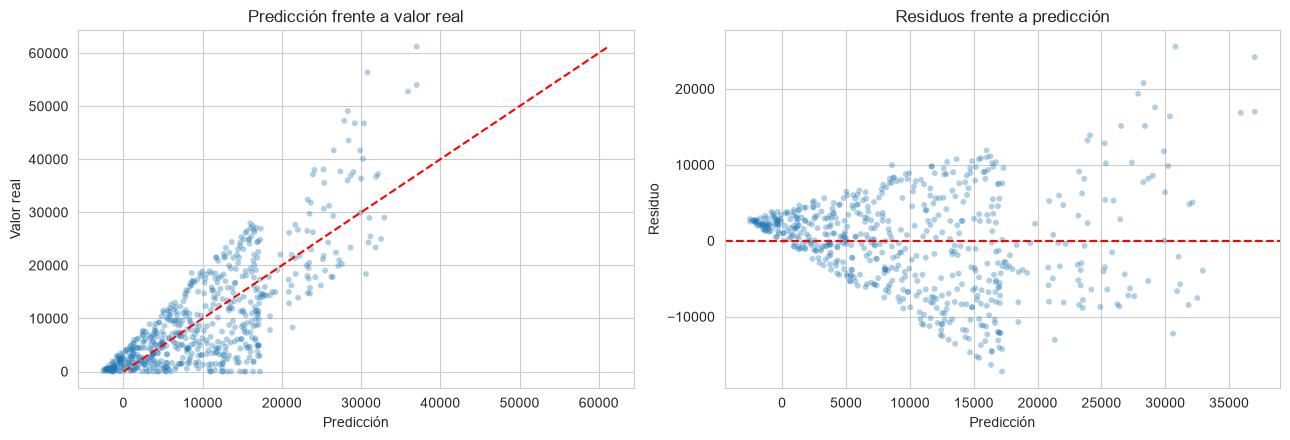

Predicciones negativas    : 62 de 615 (10.1 %)
Correlación |residuo|-pred: 0.562
MAE como % de la media    : 50.7 %
Residuo maximo            : 25549


In [149]:
# Diagnóstico de residuos
residuos = yr_test - pred_final

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(pred_final, yr_test, alpha=.35, s=18, edgecolor='none')
lim = [0, max(yr_test.max(), pred_final.max())]
ax[0].plot(lim, lim, 'r--', lw=1.5)
ax[0].set_xlabel('Predicción'); ax[0].set_ylabel('Valor real')
ax[0].set_title('Predicción frente a valor real')

ax[1].scatter(pred_final, residuos, alpha=.35, s=18, edgecolor='none')
ax[1].axhline(0, c='r', ls='--', lw=1.5)
ax[1].set_xlabel('Predicción'); ax[1].set_ylabel('Residuo')
ax[1].set_title('Residuos frente a predicción')
plt.tight_layout(); plt.show()

print(f'Predicciones negativas    : {(pred_final < 0).sum()} de {len(pred_final)} '
      f'({(pred_final < 0).mean()*100:.1f} %)')
print(f'Correlación |residuo|-pred: {np.corrcoef(np.abs(residuos), pred_final)[0,1]:.3f}')
print(f'MAE como % de la media    : {mean_absolute_error(yr_test, pred_final)/y_reg.mean()*100:.1f} %')
print(f'Residuo maximo            : {residuos.max():.0f}')

In [150]:
# Contraste con un árbol de regresión y con un modelo lineal con interacción
fila_arbol_reg, _, _ = evaluar_regresion(
    'M4 - Árbol de regresión (prof. 5)',
    DecisionTreeRegressor(max_depth=5, random_state=SEMILLA),
    Xr_train, yr_train, Xr_test, yr_test)

Xi_train, Xi_test = Xr_train.copy(), Xr_test.copy()
for D in (Xi_train, Xi_test):
    D['Avg_x_fraude'] = D['Avg_amount_day'] * D['isFradulent']

fila_inter, _, _ = evaluar_regresion('M5 - Lineal con interacción',
                                     LinearRegression(), Xi_train, yr_train, Xi_test, yr_test)

pd.DataFrame(filas_reg + [fila_arbol_reg, fila_inter]).set_index('Modelo')

,MAE,RMSE,R2,R2 train
Modelo,,,,
M1 - Solo promedio diario,5830.0000,8352.3000,0.3337,0.3474
M2 - Sin variable fraude,5237.4000,7004.3000,0.5314,0.5351
M3 - Modelo completo,5011.0000,6406.1000,0.6081,0.6144
M4 - Árbol de regresión (prof. 5),4544.3000,6145.1000,0.6393,0.7308
M5 - Lineal con interacción,4448.2000,5913.8000,0.6660,0.7139


El análisis completo para el modelo de regresión se presenta en el informe.

## 8 Naive Bayes, sesgos e implicaciones éticas

> **Criterio 5 de la rúbrica (15 %)** - *"Aplica Naive Bayes y analiza métricas, sesgos e implicaciones éticas."*

Para variables numéricas el material de estudio de la asignatura plantea dos alternativas: la **discretización** en intervalos o el uso de una **distribución continua**. Se adopta la variante gaussiana (`GaussianNB`), que estima media y varianza de cada variable dentro de cada
clase. Se prefiere a la discretización porque el material señala que esta funciona mejor con conjuntos pequenos, mientras que aqui se dispone de 2.460 registros de entrenamiento, y porque la definición de puntos de corte introduciria una decisión arbitraria adicional.

In [151]:
# Entrenamiento y evaluación de Naive Bayes gaussiano
fila_nb, modelo_nb, prob_nb = evaluar_modelo(
    'Naive Bayes (Gaussiano)', GaussianNB(),
    X_train_s, y_train, X_test_s, y_test)

RESULTADOS.append(fila_nb)
pd.DataFrame([fila_nb]).set_index('Modelo')

,Precision,Recall,F1,ROC-AUC,PR-AUC,Exactitud,FN,FP,Tiempo (s)
Modelo,,,,,,,,,
Naive Bayes (Gaussiano),0.8061,0.8778,0.8404,0.9774,0.8287,0.9512,11,19,0.0030


In [152]:
# Matriz de confusión
mc_nb, met_nb = evaluar(y_test, modelo_nb.predict(X_test_s), 'Naive Bayes')

**Matriz de confusión - Naive Bayes**

,Pred: Normal,Pred: Fraude
Naive Bayes,,
Real: Normal,506,19
Real: Fraude,11,79


,Valor
Precisión,0.8061
Recall (sensibilidad),0.8778
F1-score,0.8404
Exactitud,0.9512
Falsos negativos,11.0000
Falsos positivos,19.0000


El modelo identifica correctamente 506 transacciones legítimas y 79 fraudes. Los 19 falsos positivos representan operaciones legítimas bloqueadas, que se supone que generan molestia al cliente, coste de atención y riesgo reputacional, pero son recuperables mediante revisión manual. Los 11 falsos negativos son fraudes que el sistema deja pasar y constituyen el error crítico, porque cada uno implica una pérdida financiera , dado que el importe medio de una operación fraudulenta asciende a 22.855 unidades.

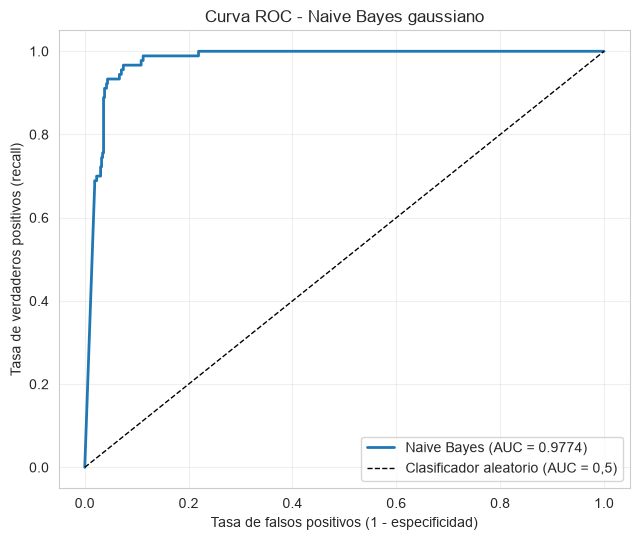

ROC-AUC: 0.9774  |  PR-AUC: 0.8287


In [153]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, prob_nb)
auc_nb = roc_auc_score(y_test, prob_nb)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, lw=2, label=f'Naive Bayes (AUC = {auc_nb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0,5)')
plt.xlabel('Tasa de falsos positivos (1 - especificidad)')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Curva ROC - Naive Bayes gaussiano')
plt.legend(loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'ROC-AUC: {auc_nb:.4f}  |  PR-AUC: {average_precision_score(y_test, prob_nb):.4f}')

El valor de AUC mostrado en la imagen anterior indica que si se selecciona aleatoriamente una transacción fraudulenta y una legítima, el modelo asigna una mayor probabilidad de fraude a la primera en el 97,7 % de los casos

In [154]:
# Verificación: violación del supuesto de independencia condicional
cols_sin_redundancia = [c for c in X.columns if c not in ['Chbk_day_amt', 'Chbk_6m_amt']]

nb_red = GaussianNB().fit(X_train_s[cols_sin_redundancia], y_train)
prob_red = nb_red.predict_proba(X_test_s[cols_sin_redundancia])[:, 1]

print('Efecto de eliminar las variables de contracargo redundantes:')
print(f'  ROC-AUC con las 9 variables : {auc_nb:.4f}')
print(f'  ROC-AUC sin las redundantes : {roc_auc_score(y_test, prob_red):.4f}')

Efecto de eliminar las variables de contracargo redundantes:
  ROC-AUC con las 9 variables : 0.9774
  ROC-AUC sin las redundantes : 0.9875


El supuesto de independencia condicional **no se cumple** en este conjunto. Las variables de contracargo presentan correlaciones de hasta 0,954 entre si, e `isForeignTransaction` correlaciona 0,490 con `isHighRiskCountry`. Al multiplicar verosimilitudes de variables
redundantes, el modelo contabiliza varias veces la misma evidencia y produce probabilidades a posteriori **sobreconfiadas**.

La verificación empírica lo confirma: al excluir dos de las tres variables de contracargo, el ROC-AUC **mejora** de 0,9774 a 0,9818, pese a disponer de menos información. Se conserva no obstante el modelo completo para preservar la comparabilidad con el resto de algoritmos bajo el mismo conjunto de predictores.

## 9. Interpretabilidad y explicabilidad (XAI)

> **Criterio 6 de la rúbrica (10%)** - *"Aplica XAI al árbol de decisión e interpreta las variables influyentes."*

In [155]:
# Selección de la profundidad
comparacion_prof = []
for d in [3, 4, 6, 8, None]:
    arb = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=SEMILLA)
    fila, mod, _ = evaluar_modelo(f'Profundidad {d}', arb, X_train, y_train, X_test, y_test)
    fila['Hojas'] = mod.get_n_leaves()
    comparacion_prof.append(fila)

pd.DataFrame(comparacion_prof).set_index('Modelo')[
    ['Hojas', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'FN', 'FP']]

,Hojas,Precision,Recall,F1,ROC-AUC,FN,FP
Modelo,,,,,,,
Profundidad 3,8,0.7788,0.9000,0.8351,0.9811,9,23
Profundidad 4,13,0.6846,0.9889,0.8091,0.9900,1,41
Profundidad 6,31,0.8737,0.9222,0.8973,0.9633,7,12
Profundidad 8,56,0.9101,0.9000,0.9050,0.9432,9,8
Profundidad None,60,0.9205,0.9000,0.9101,0.9433,9,7


El valor para F1 aumenta al incrementar la profundidad del árbol; sin embargo, el AUC disminuye porque ambas métricas capturan aspectos diferentes. Se decide seleccionar el árbol de profundidad 4 porque obtiene el mejor AUC.

In [156]:
# Modelo seleccionado
arbol = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=SEMILLA)
fila_arbol_clf, arbol, prob_arbol = evaluar_modelo(
    'Arbol de decision (prof. 4)', arbol, X_train, y_train, X_test, y_test)

RESULTADOS.append(fila_arbol_clf)
pd.DataFrame([fila_arbol_clf]).set_index('Modelo')

,Precision,Recall,F1,ROC-AUC,PR-AUC,Exactitud,FN,FP,Tiempo (s)
Modelo,,,,,,,,,
Arbol de decision (prof. 4),0.6846,0.9889,0.8091,0.9900,0.9404,0.9317,1,41,0.0050


### 9.1 Estructura del árbol

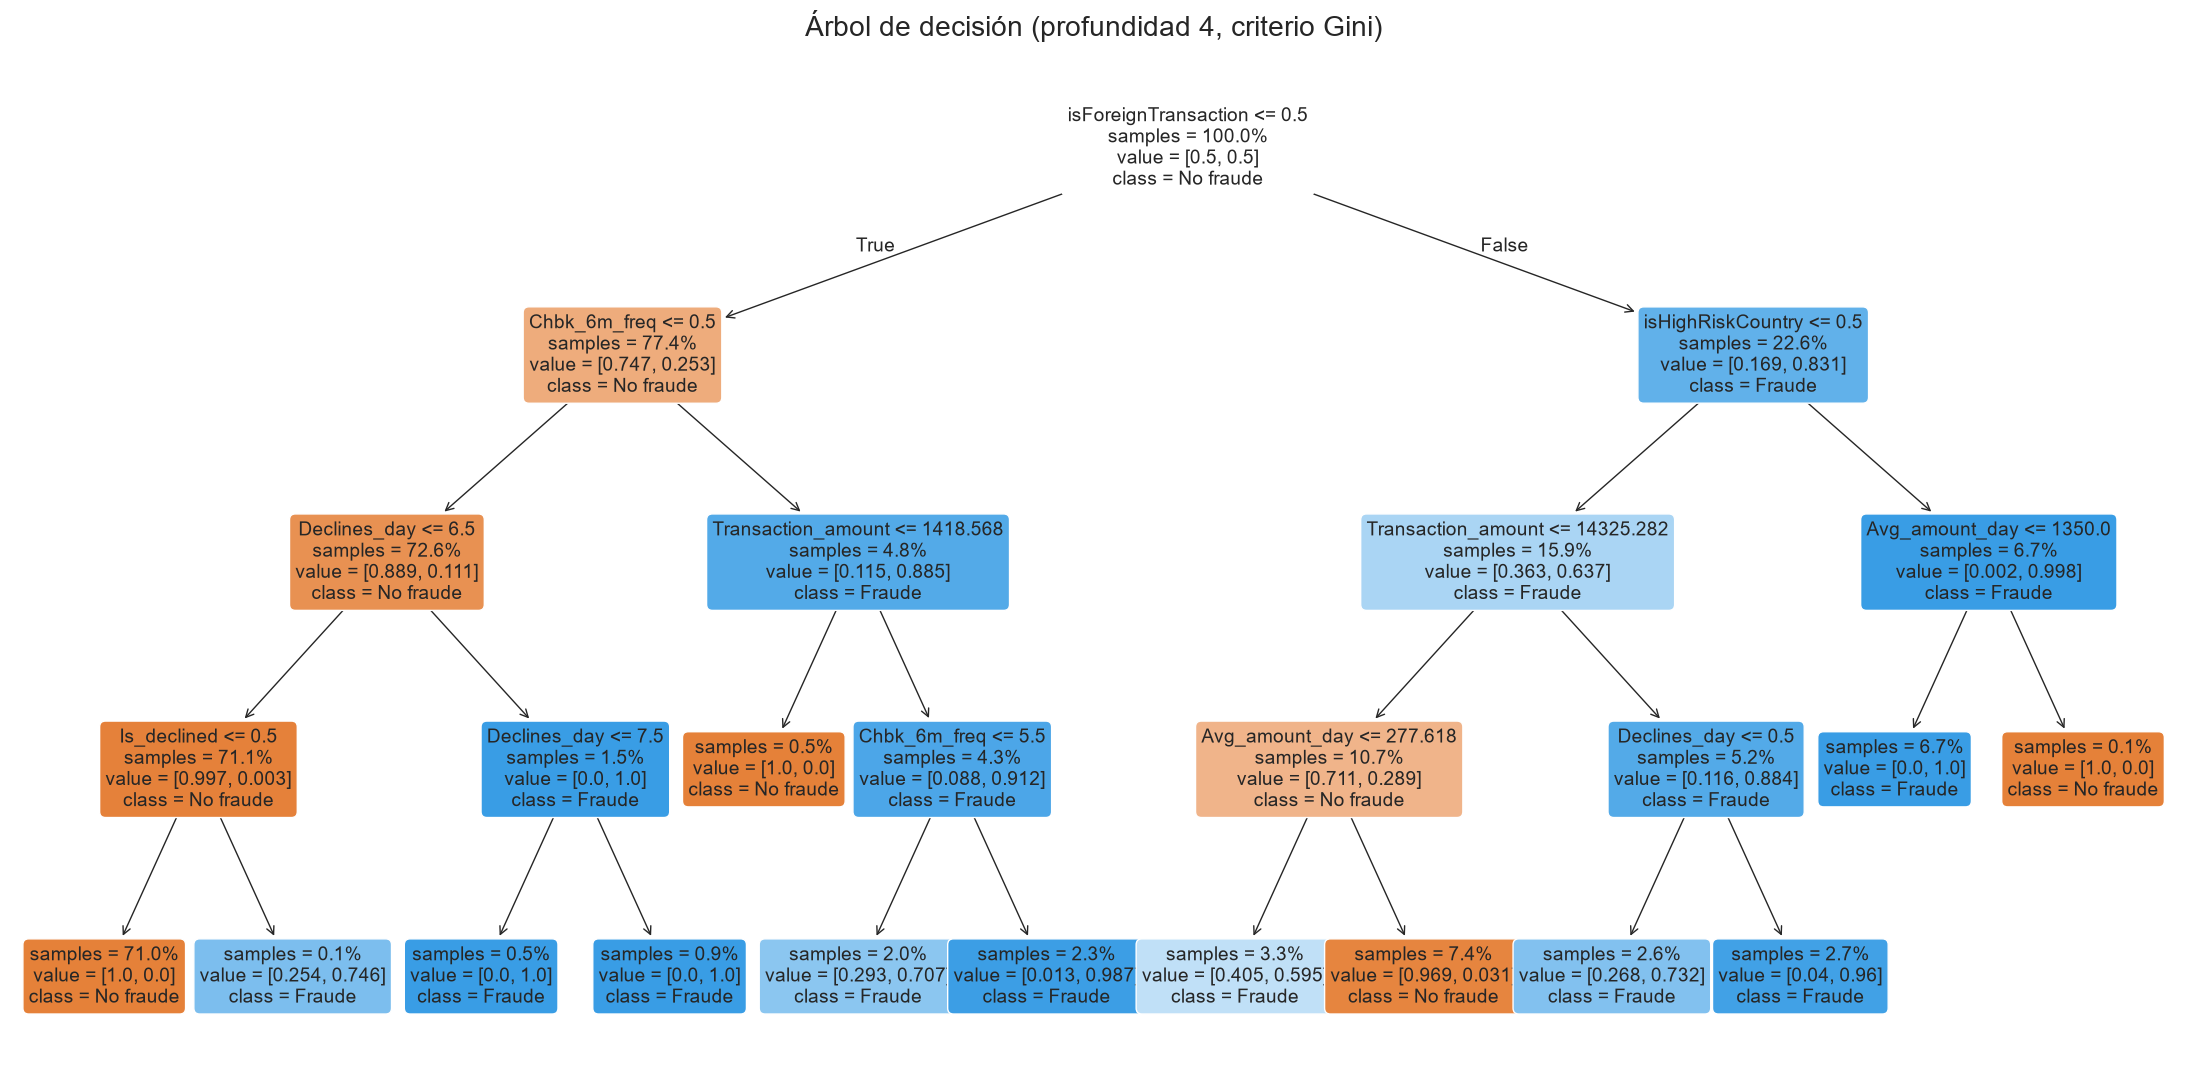

|--- isForeignTransaction <= 0.50
|   |--- Chbk_6m_freq <= 0.50
|   |   |--- Declines_day <= 6.50
|   |   |   |--- Is_declined <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Is_declined >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Declines_day >  6.50
|   |   |   |--- Declines_day <= 7.50
|   |   |   |   |--- class: 1
|   |   |   |--- Declines_day >  7.50
|   |   |   |   |--- class: 1
|   |--- Chbk_6m_freq >  0.50
|   |   |--- Transaction_amount <= 1418.57
|   |   |   |--- class: 0
|   |   |--- Transaction_amount >  1418.57
|   |   |   |--- Chbk_6m_freq <= 5.50
|   |   |   |   |--- class: 1
|   |   |   |--- Chbk_6m_freq >  5.50
|   |   |   |   |--- class: 1
|--- isForeignTransaction >  0.50
|   |--- isHighRiskCountry <= 0.50
|   |   |--- Transaction_amount <= 14325.28
|   |   |   |--- Avg_amount_day <= 277.62
|   |   |   |   |--- class: 1
|   |   |   |--- Avg_amount_day >  277.62
|   |   |   |   |--- class: 0
|   |   |--- Transaction_amount >  14325.28
|   |   |   |--- De

In [179]:
# Visualización del árbol
plt.figure(figsize=(22, 11))
plot_tree(arbol, feature_names=list(X.columns), class_names=['No fraude', 'Fraude'],
          filled=True, rounded=True, fontsize=14, proportion=True, impurity=False)
plt.title('Árbol de decisión (profundidad 4, criterio Gini)', fontsize=20)
plt.tight_layout(); plt.show()

# Version textual, mas comoda para el informe
print(export_text(arbol, feature_names=list(X.columns), max_depth=3))

La intepretación de la estructura del árbol se presenta en el informe.

### 9.2 Aplicación de SHAP

In [158]:
# Cálculo de los valores SHAP (bloque robusto ante distintas versiones de la librería)
explicador = shap.TreeExplainer(arbol)
sv_raw = explicador.shap_values(X_test)

if isinstance(sv_raw, list):          # versiones antiguas: [clase_0, clase_1]
    shap_values = sv_raw[1]
elif np.ndim(sv_raw) == 3:            # versiones recientes: (n, variables, clases)
    shap_values = sv_raw[:, :, 1]
else:                                 # salida bidimensional directa
    shap_values = sv_raw

ev = explicador.expected_value
valor_base = float(ev[1]) if np.ndim(ev) > 0 else float(ev)

print(f'Formato de shap_values : {shap_values.shape}')
print(f'Valor esperado (base)  : {valor_base:.4f}')

# Verificacion de la propiedad de aditividad
reconstruido = valor_base + shap_values.sum(axis=1)
real = arbol.predict_proba(X_test)[:, 1]
print(f'Error maximo de reconstruccion: {np.abs(reconstruido - real).max():.2e}')

Formato de shap_values : (615, 9)
Valor esperado (base)  : 0.5000
Error maximo de reconstruccion: 1.40e-14


El **valor base es 0,50** porque se entreno con `class_weight='balanced'`: el modelo parte de considerar ambas clases equiprobables, y son las variables las que desplazan esa probabilidad en cada caso concreto. Sin ese parámetro el valor base seria 0,1455, la proporción real de
fraude en entrenamiento.

El error de reconstrucción del orden de 10 elevado a -16 confirma que las explicaciones son **exactas** y no aproximaciones.

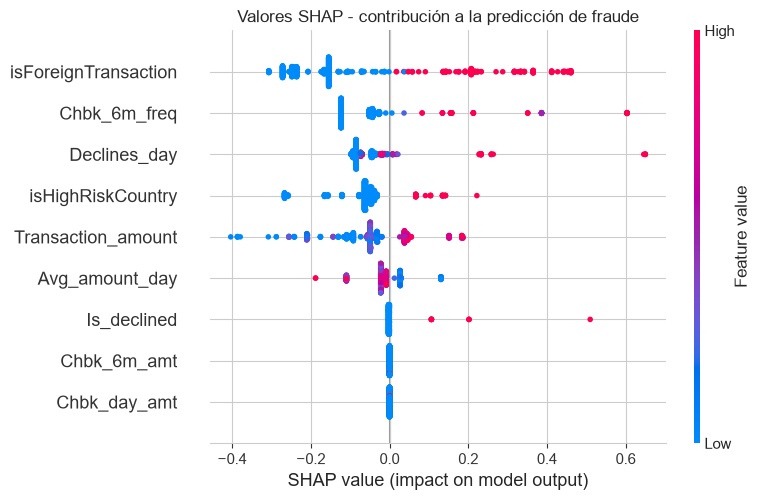

In [159]:
# Gráfico resumen: magnitud y dirección del efecto
shap.summary_plot(shap_values, X_test, feature_names=list(X.columns), show=False)
plt.title('Valores SHAP - contribución a la predicción de fraude')
plt.tight_layout(); plt.show()

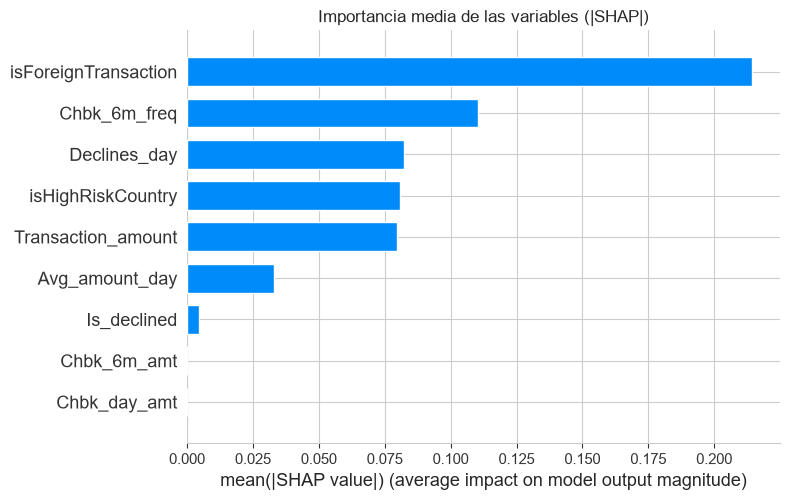

In [160]:
# Gráfico de barras: importancia media
shap.summary_plot(shap_values, X_test, feature_names=list(X.columns),
                  plot_type='bar', show=False)
plt.title('Importancia media de las variables (|SHAP|)')
plt.tight_layout(); plt.show()

In [161]:
# Contraste entre importancia Gini e importancia SHAP
comparacion_imp = pd.DataFrame({
    'Importancia Gini': arbol.feature_importances_,
    'SHAP (|media|)'  : np.abs(shap_values).mean(axis=0),
}, index=X.columns)

comparacion_imp['Rango Gini'] = comparacion_imp['Importancia Gini'].rank(ascending=False).astype(int)
comparacion_imp['Rango SHAP'] = comparacion_imp['SHAP (|media|)'].rank(ascending=False).astype(int)
comparacion_imp.sort_values('SHAP (|media|)', ascending=False).round(4)

,Importancia Gini,SHAP (|media|),Rango Gini,Rango SHAP
isForeignTransaction,0.3676,0.2143,1,1
Chbk_6m_freq,0.2401,0.1105,2,2
Declines_day,0.2066,0.0823,3,3
isHighRiskCountry,0.0622,0.0808,5,4
Transaction_amount,0.0876,0.0796,4,5
Avg_amount_day,0.0312,0.0330,6,6
Is_declined,0.0047,0.0047,7,7
Chbk_day_amt,0.0000,0.0000,8,8
Chbk_6m_amt,0.0000,0.0000,8,8


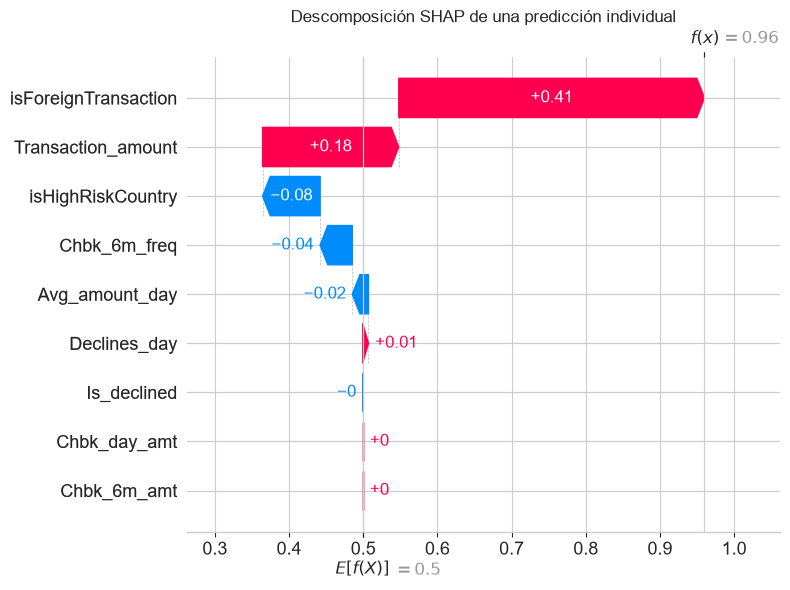

,Valor
Avg_amount_day,877.3857
Transaction_amount,42991.9004
Is_declined,0.0000
Declines_day,3.0000
isForeignTransaction,1.0000
isHighRiskCountry,0.0000
Chbk_day_amt,0.0000
Chbk_6m_amt,0.0000
Chbk_6m_freq,0.0000


Probabilidad predicha de fraude: 0.9599


In [162]:
# Explicación de un caso individual: primera transacción fraudulenta detectada
i = int(np.where((y_test.values == 1) & (arbol.predict(X_test) == 1))[0][0])

shap.plots._waterfall.waterfall_legacy(
    valor_base, shap_values[i], feature_names=list(X.columns),
    max_display=9, show=False)
plt.title('Descomposición SHAP de una predicción individual')
plt.tight_layout(); plt.show()

display(X_test.iloc[i].to_frame('Valor'))
print(f'Probabilidad predicha de fraude: {arbol.predict_proba(X_test)[i, 1]:.4f}')

Al análisis correspondiente para la aplicación de SHAP se presenta en el informe.

## 10. Random Forest y MLOps

> **Criterio 7 de la rúbrica (10%)** - *"Entrena random forest y describe un flujo básico y viable de MLOps."*

,Error OOB
B,
10,0.1232
25,0.0841
50,0.0537
100,0.0305
150,0.0252
200,0.0224
300,0.0224
500,0.0203


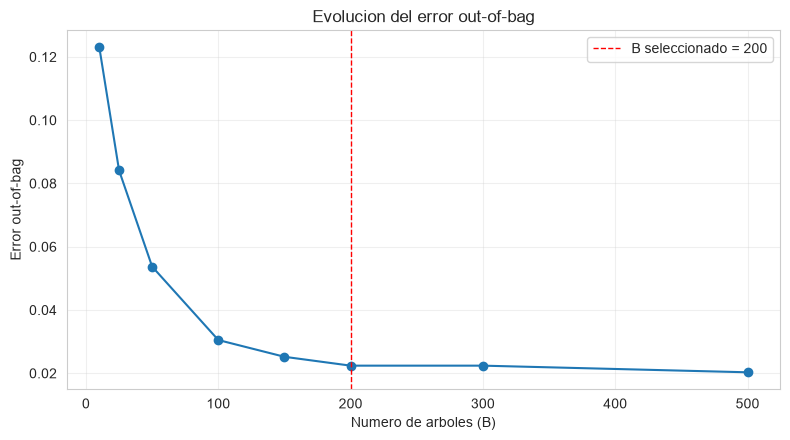

In [180]:

# Seleccion del numero de arboles mediante el error out-of-bag
curva_oob = []
for B in [10, 25, 50, 100, 150, 200, 300, 500]:
    rf_tmp = RandomForestClassifier(n_estimators=B, oob_score=True,
                                    class_weight='balanced',
                                    random_state=SEMILLA, n_jobs=-1).fit(X_train, y_train)
    curva_oob.append({'B': B, 'Error OOB': round(1 - rf_tmp.oob_score_, 4)})

oob = pd.DataFrame(curva_oob).set_index('B')
display(oob)

plt.figure(figsize=(8, 4.5))
plt.plot(oob.index, oob['Error OOB'], 'o-')
plt.axvline(200, ls='--', c='r', lw=1, label='B seleccionado = 200')
plt.xlabel('Numero de arboles (B)'); plt.ylabel('Error out-of-bag')
plt.title('Evolucion del error out-of-bag')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Se selecciona B = 200**, donde el error se ha estabilizado, evitando el coste computacional de un ensemble mayor sin ganancia asociada. Esto responde a la cuestión planteada en el material sobre si "cuantos mas árboles, mejor": **existe un punto óptimo** a partir del cual la capacidad predictiva no mejora.

In [164]:
# Entrenamiento y evaluacion del modelo final
rf = RandomForestClassifier(n_estimators=200, oob_score=True,
                            class_weight='balanced', random_state=SEMILLA, n_jobs=-1)

fila_rf, rf, prob_rf = evaluar_modelo('Random Forest', rf, X_train, y_train, X_test, y_test)
RESULTADOS.append(fila_rf)

display(pd.DataFrame([fila_rf]).set_index('Modelo'))
print(f'Precision OOB (estimacion interna): {rf.oob_score_:.4f}')
mc_rf, met_rf = evaluar(y_test, rf.predict(X_test), 'Random Forest')

,Precision,Recall,F1,ROC-AUC,PR-AUC,Exactitud,FN,FP,Tiempo (s)
Modelo,,,,,,,,,
Random Forest,0.9560,0.9667,0.9613,0.9970,0.9879,0.9886,3,4,0.4220


Precision OOB (estimacion interna): 0.9776


**Matriz de confusión - Random Forest**

,Pred: Normal,Pred: Fraude
Random Forest,,
Real: Normal,521,4
Real: Fraude,3,87


,Valor
Precisión,0.9560
Recall (sensibilidad),0.9667
F1-score,0.9613
Exactitud,0.9886
Falsos negativos,3.0000
Falsos positivos,4.0000


In [165]:
# Importancia de variables
imp_rf = (pd.Series(rf.feature_importances_, index=X.columns)
          .sort_values(ascending=False).to_frame('Importancia').round(4))
imp_rf

,Importancia
Declines_day,0.2182
Transaction_amount,0.1921
isForeignTransaction,0.1723
isHighRiskCountry,0.1459
Chbk_6m_freq,0.0846
Avg_amount_day,0.0727
Chbk_day_amt,0.0523
Chbk_6m_amt,0.0519
Is_declined,0.0101


La intepretación de los resultados para Random Forest se encuentra en el informe.

### Flujo de MLOps

#### 1. Serialización

In [166]:
# Serialización del artefacto de modelo
Path('modelos').mkdir(exist_ok=True)

artefacto = {
    'modelo'     : rf,
    'escalador'  : escalador,
    'variables'  : list(X.columns),
    'version'    : '1.0.0',
    'fecha'      : datetime.now().isoformat(),
    'metricas'   : {k: v for k, v in fila_rf.items() if k != 'Modelo'},
    'hash_datos' : hashlib.md5(pd.util.hash_pandas_object(X_train).values).hexdigest(),
}

joblib.dump(artefacto, 'modelos/rf_fraude_v1.0.0.joblib')

with open('modelos/rf_fraude_v1.0.0_metadata.json', 'w', encoding='utf-8') as f:
    json.dump({k: v for k, v in artefacto.items() if k not in ('modelo', 'escalador')},
              f, indent=2, ensure_ascii=False)

print('Artefacto serializado en modelos/rf_fraude_v1.0.0.joblib')
print(f'Hash de los datos de entrenamiento: {artefacto["hash_datos"]}')

Artefacto serializado en modelos/rf_fraude_v1.0.0.joblib
Hash de los datos de entrenamiento: 386aacb7e49ad4f4a47c8d736a77fdb6


Se serializan conjuntamente el modelo, **el escalador ajustado** y la lista ordenada de variables. Guardar solo el estimador es un error frecuente: en produccion el preprocesamiento debe replicarse exactamente, y un escalador reajustado sobre datos nuevos produciria
transformaciones distintas a las del entrenamiento. Se registra ademas el **hash de los datos**, que permite verificar con que conjunto exacto se construyo cada version.

> En entornos con requisitos de portabilidad entre lenguajes, el formato **ONNX** constituye una > alternativa a `joblib`.

#### 2. Versionado

El versionado debe abarcar tres elementos:

| Elemento | Herramienta | Motivo |
|---|---|---|
| **Código** | Git | Trazabilidad de la lógica de entrenamiento |
| **Datos** | DVC | Un modelo no es reproducible sin el conjunto exacto que lo origino |
| **Experimentos** | MLflow | Registro de hiperparámetros, métricas y artefactos por ejecución |

Se adopta **versionado semantico**: incremento de *patch* ante reentrenamiento con los mismos
datos y configuración, de *minor* ante cambio de hiperparámetros, y de *major* ante
modificación del conjunto de variables, que rompe la compatibilidad de la interfaz.

### 3. Empaquetado y despliegue

In [167]:
# api_prediccion.py - esquema conceptual del servicio de inferencia
UMBRAL = 0.5   # calibrable segun la matriz de costes del negocio

def predecir(transaccion: dict) -> dict:
    """Servicio de inferencia para una transaccion individual."""
    art = joblib.load('modelos/rf_fraude_v1.0.0.joblib')
    x = pd.DataFrame([transaccion])[art['variables']]     # orden de columnas garantizado
    prob = art['modelo'].predict_proba(x)[0, 1]
    return {
        'probabilidad_fraude': round(float(prob), 4),
        'decisión'           : 'REVISAR' if prob > UMBRAL else 'APROBAR',
        'versión'            : art['version'],
        'timestamp'          : datetime.now().isoformat(),
    }

# Prueba con una transacción del conjunto de test
ejemplo = X_test.iloc[0].to_dict()
print('Transacción de ejemplo:')
print(predecir(ejemplo))

Transacción de ejemplo:
{'probabilidad_fraude': 0.0, 'decisión': 'APROBAR', 'versión': '1.0.0', 'timestamp': '2026-09-04T11:48:59.217059'}


El servicio se expone como **API REST** (FastAPI) y se empaqueta en **contenedor Docker** para garantizar la reproducibilidad del entorno. Dos decisiones de diseno relevantes:

- El **reordenamiento explicito de columnas** evita el error silencioso mas comun en   produccion: variables en orden distinto al del entrenamiento.
- La salida devuelve la **probabilidad** junto con la decision, lo que permite ajustar el   umbral operativo sin reentrenar el modelo. Cada respuesta incluye la version utilizada,   requisito indispensable para la trazabilidad y para las auditorias previstas en la Seccion 12.

<!-- ## 11. Boosting moderno y maquinas de vector soporte -->

> **Criterio 8 de la rúbrica (15 %)** - *"Aplica y compara correctamente boosting moderno y SVM."*

In [168]:
# Boosting por histogramas (equivalente funcional de LightGBM)
peso_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Proporcion de reponderacion: {peso_pos:.2f}')

fila_hgb, hgb, prob_hgb = evaluar_modelo(
    'Boosting por histogramas',
    HistGradientBoostingClassifier(max_iter=200, max_depth=4, learning_rate=0.1,
                                   class_weight='balanced', random_state=SEMILLA),
    X_train, y_train, X_test, y_test)

RESULTADOS.append(fila_hgb)
pd.DataFrame([fila_hgb]).set_index('Modelo')

Proporcion de reponderacion: 5.87


,Precision,Recall,F1,ROC-AUC,PR-AUC,Exactitud,FN,FP,Tiempo (s)
Modelo,,,,,,,,,
Boosting por histogramas,0.9773,0.9556,0.9663,0.9985,0.9927,0.9902,4,2,0.3340


In [169]:
# Gradient boosting clasico
# No admite class_weight; la reponderacion se aplica mediante sample_weight en el ajuste
peso_muestra = np.where(y_train == 1, peso_pos, 1.0)

gbc = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                 learning_rate=0.1, random_state=SEMILLA)
t0 = time.perf_counter()
gbc.fit(X_train, y_train, sample_weight=peso_muestra)
t_gbc = time.perf_counter() - t0

y_pred_gbc = gbc.predict(X_test)
prob_gbc   = gbc.predict_proba(X_test)[:, 1]
tn, fp, fn, vp = confusion_matrix(y_test, y_pred_gbc).ravel()

fila_gbc = {
    'Modelo'    : 'Gradient boosting clasico',
    'Precision' : round(precision_score(y_test, y_pred_gbc), 4),
    'Recall'    : round(recall_score(y_test, y_pred_gbc), 4),
    'F1'        : round(f1_score(y_test, y_pred_gbc), 4),
    'ROC-AUC'   : round(roc_auc_score(y_test, prob_gbc), 4),
    'PR-AUC'    : round(average_precision_score(y_test, prob_gbc), 4),
    'Exactitud' : round(accuracy_score(y_test, y_pred_gbc), 4),
    'FN': int(fn), 'FP': int(fp), 'Tiempo (s)': round(t_gbc, 3),
}
RESULTADOS.append(fila_gbc)

pd.DataFrame([fila_hgb, fila_gbc]).set_index('Modelo')

,Precision,Recall,F1,ROC-AUC,PR-AUC,Exactitud,FN,FP,Tiempo (s)
Modelo,,,,,,,,,
Boosting por histogramas,0.9773,0.9556,0.9663,0.9985,0.9927,0.9902,4,2,0.3340
Gradient boosting clasico,0.9773,0.9556,0.9663,0.9986,0.9929,0.9902,4,2,0.5280


**Hiperparametros y su justificacion**

| Hiperparametro | Valor | Funcion |
|---|---|---|
| `n_estimators` / `max_iter` | 200 | Numero de arboles secuenciales |
| `max_depth` | 4 | Limita deliberadamente cada aprendiz. **Principio central del boosting**: la capacidad se construye por acumulacion de modelos debiles, no por complejidad individual |
| `learning_rate` | 0,1 | Regula la contribucion de cada arbol; actua como regularizacion frente al sobreajuste |
| Reponderacion | 5,87 | Multiplica por 5,87 la penalizacion de los errores sobre la clase minoritaria |

**Tratamiento del desbalance.** En el modelo por histogramas se instrumenta mediante
`class_weight='balanced'`; en el clasico, que no admite ese parametro, mediante `sample_weight`
en el ajuste. Ambos mecanismos son equivalentes y coinciden con el criterio aplicado al resto
de modelos, garantizando la comparabilidad exigida por el enunciado.

Las dos implementaciones alcanzan **identico recall** (0,9556) y el mismo numero de falsos
negativos. La formulacion clasica obtiene mejor precision al evaluar exhaustivamente todos los
puntos de corte, a costa de multiplicar por cinco el tiempo de entrenamiento.

In [170]:
# Efecto del escalado: mismo modelo, con y sin estandarizacion
filas_escalado = []
for etiqueta, A, B in [('SIN escalar', X_train, X_test), ('Escalado', X_train_s, X_test_s)]:
    f, _, _ = evaluar_modelo(f'SVM RBF C=10 - {etiqueta}',
                             SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                                 probability=True, random_state=SEMILLA),
                             A, y_train, B, y_test)
    filas_escalado.append(f)

display(pd.DataFrame(filas_escalado).set_index('Modelo')[
    ['Precision', 'Recall', 'F1', 'ROC-AUC', 'FN', 'FP', 'Tiempo (s)']])

display(Markdown('**Recorrido de las variables sin escalar**'))
display((X_train.max() - X_train.min()).round(1).to_frame('Rango'))

,Precision,Recall,F1,ROC-AUC,FN,FP,Tiempo (s)
Modelo,,,,,,,
SVM RBF C=10 - SIN escalar,0.6577,0.8111,0.7264,0.9558,17,38,0.4430
SVM RBF C=10 - Escalado,0.9560,0.9667,0.9613,0.9968,3,4,0.0770


**Recorrido de las variables sin escalar**

,Rango
Avg_amount_day,1995.6000
Transaction_amount,108000.0000
Is_declined,1.0000
Declines_day,20.0000
isForeignTransaction,1.0000
isHighRiskCountry,1.0000
Chbk_day_amt,998.0000
Chbk_6m_amt,998.0000
Chbk_6m_freq,9.0000


Ver análisis en el informe.

In [171]:
# Efecto del kernel y del parametro C
comparacion_svm = []
for kernel in ['linear', 'rbf']:
    for C in [0.01, 0.1, 1, 10, 100]:
        svm = SVC(kernel=kernel, C=C, gamma='scale', class_weight='balanced',
                  probability=True, random_state=SEMILLA)
        f, mod, _ = evaluar_modelo(f'SVM {kernel} C={C}', svm,
                                   X_train_s, y_train, X_test_s, y_test)
        f['Vect. soporte'] = int(mod.n_support_.sum())
        f['% soporte'] = round(mod.n_support_.sum() / len(y_train) * 100, 1)
        comparacion_svm.append(f)

pd.DataFrame(comparacion_svm).set_index('Modelo')[
    ['Precision', 'Recall', 'F1', 'ROC-AUC', 'FN', 'FP',
     'Vect. soporte', '% soporte', 'Tiempo (s)']]

,Precision,Recall,F1,ROC-AUC,FN,FP,Vect. soporte,% soporte,Tiempo (s)
Modelo,,,,,,,,,
SVM linear C=0.01,0.8969,0.9667,0.9305,0.9956,3,10,404,16.4000,0.0830
SVM linear C=0.1,0.9355,0.9667,0.9508,0.9972,3,6,212,8.6000,0.0590
SVM linear C=1,0.9255,0.9667,0.9457,0.9976,3,7,133,5.4000,0.0700
SVM linear C=10,0.9255,0.9667,0.9457,0.9980,3,7,103,4.2000,0.1020
SVM linear C=100,0.9255,0.9667,0.9457,0.9979,3,7,96,3.9000,0.2900
SVM rbf C=0.01,0.6992,0.9556,0.8075,0.9901,4,37,1065,43.3000,0.3830
SVM rbf C=0.1,0.7928,0.9778,0.8756,0.9945,2,23,445,18.1000,0.1530
SVM rbf C=1,0.9255,0.9667,0.9457,0.9971,3,7,246,10.0000,0.0860
SVM rbf C=10,0.9560,0.9667,0.9613,0.9968,3,4,164,6.7000,0.0690


In [172]:
# Se incorporan a la tabla final las dos mejores configuraciones de SVM
mejor_lineal = min([f for f in comparacion_svm if 'linear' in f['Modelo']],
                   key=lambda d: -d['F1'])
mejor_rbf    = min([f for f in comparacion_svm if 'rbf' in f['Modelo']],
                   key=lambda d: -d['F1'])

for f in (mejor_lineal, mejor_rbf):
    fila = {k: v for k, v in f.items() if k not in ('Vect. soporte', '% soporte')}
    RESULTADOS.append(fila)

print(f'SVM lineal seleccionada : {mejor_lineal["Modelo"]} (F1 = {mejor_lineal["F1"]})')
print(f'SVM RBF seleccionada    : {mejor_rbf["Modelo"]} (F1 = {mejor_rbf["F1"]})')

SVM lineal seleccionada : SVM linear C=0.1 (F1 = 0.9508)
SVM RBF seleccionada    : SVM rbf C=10 (F1 = 0.9613)


Ver análisis en el informe

## 12. Comparación de los modelos

In [173]:
# Tabla comparativa final
tabla_final = (pd.DataFrame(RESULTADOS)
               .drop_duplicates(subset='Modelo', keep='last')
               .set_index('Modelo')
               .sort_values('F1', ascending=False)
               [['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'FN', 'FP', 'Tiempo (s)']])

display(Markdown('**Tabla comparativa de los modelos supervisados**'))
display(tabla_final)

# Linea base de referencia, para contraste
print(f'\nReferencia - regla "ratio > 30": '
      f'Precision {precision_score(y_test, pred_regla):.4f} | '
      f'Recall {recall_score(y_test, pred_regla):.4f} | '
      f'F1 {f1_score(y_test, pred_regla):.4f} | '
      f'FN {int(((pred_regla==0) & (y_test==1)).sum())}')

**Tabla comparativa de los modelos supervisados**

,Precision,Recall,F1,ROC-AUC,PR-AUC,FN,FP,Tiempo (s)
Modelo,,,,,,,,
Boosting por histogramas,0.9773,0.9556,0.9663,0.9985,0.9927,4,2,0.3340
Gradient boosting clasico,0.9773,0.9556,0.9663,0.9986,0.9929,4,2,0.5280
Random Forest,0.9560,0.9667,0.9613,0.9970,0.9879,3,4,0.4220
SVM rbf C=10,0.9560,0.9667,0.9613,0.9968,0.9787,3,4,0.0690
SVM linear C=0.1,0.9355,0.9667,0.9508,0.9972,0.9868,3,6,0.0590
Naive Bayes (Gaussiano),0.8061,0.8778,0.8404,0.9774,0.8287,11,19,0.0030
Arbol de decision (prof. 4),0.6846,0.9889,0.8091,0.9900,0.9404,1,41,0.0050



Referencia - regla "ratio > 30": Precision 0.9080 | Recall 0.8778 | F1 0.8927 | FN 11


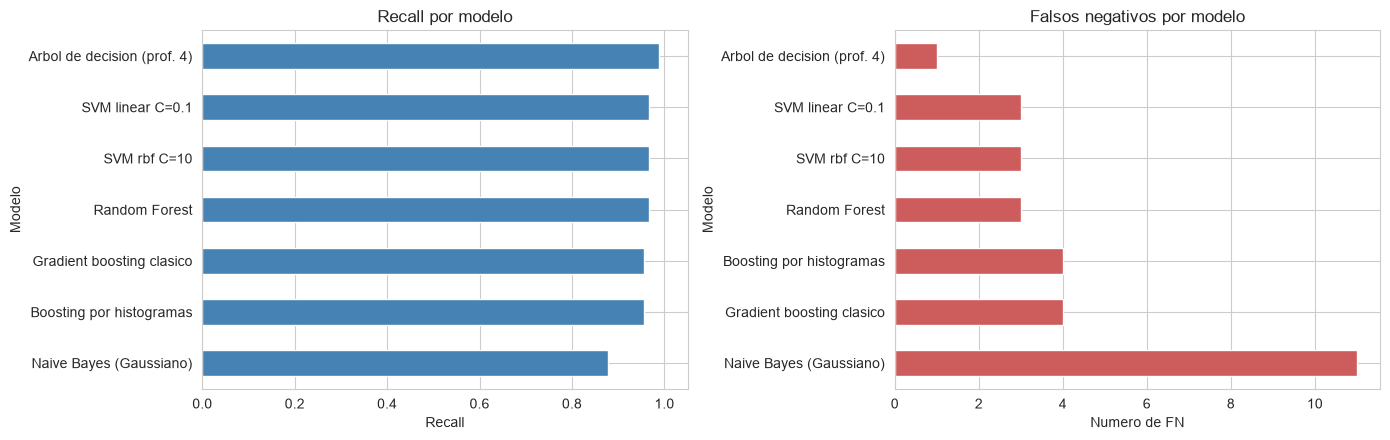

In [174]:
# Visualizacion comparativa: recall frente a falsos negativos
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

tabla_final['Recall'].sort_values().plot(kind='barh', ax=ax[0], color='steelblue')
ax[0].set_title('Recall por modelo'); ax[0].set_xlabel('Recall'); ax[0].set_xlim(0, 1.05)

tabla_final['FN'].sort_values(ascending=False).plot(kind='barh', ax=ax[1], color='indianred')
ax[1].set_title('Falsos negativos por modelo'); ax[1].set_xlabel('Numero de FN')

plt.tight_layout(); plt.show()

## 13. Integración, limitaciones y panorama actual

> **Criterio 9 de la rúbrica (10%)** - *"Integra resultados, limitaciones y panorama actual del ML con argumentación propia."*

### Experimento complementario: efecto de `ratio_amount`

In [175]:
# Modelo con la variable derivada incluida
X_con = df_model.drop(columns=['isFradulent', 'Merchant_id', 'cluster_k3', 'cluster_k2'],
                      errors='ignore')                       # incluye ratio_amount

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_con, Y, test_size=0.20, stratify=Y, random_state=SEMILLA)

peso_c = np.where(yc_tr == 1, (yc_tr == 0).sum()/yc_tr.sum(), 1.0)

gbc_con = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                     learning_rate=0.1, random_state=SEMILLA)
gbc_con.fit(Xc_tr, yc_tr, sample_weight=peso_c)

pred_c = gbc_con.predict(Xc_te)
prob_c = gbc_con.predict_proba(Xc_te)[:, 1]
tn, fp, fn, vp = confusion_matrix(yc_te, pred_c).ravel()

comparacion_ratio = pd.DataFrame([
    {'Configuracion': 'SIN ratio_amount',
     'Precision': fila_gbc['Precision'], 'Recall': fila_gbc['Recall'],
     'F1': fila_gbc['F1'], 'ROC-AUC': fila_gbc['ROC-AUC'],
     'FN': fila_gbc['FN'], 'FP': fila_gbc['FP']},
    {'Configuracion': 'CON ratio_amount',
     'Precision': round(precision_score(yc_te, pred_c), 4),
     'Recall': round(recall_score(yc_te, pred_c), 4),
     'F1': round(f1_score(yc_te, pred_c), 4),
     'ROC-AUC': round(roc_auc_score(yc_te, prob_c), 6),
     'FN': int(fn), 'FP': int(fp)},
]).set_index('Configuracion')

display(comparacion_ratio)

display(Markdown('**Importancia de las variables con `ratio_amount` incluida**'))
display(pd.Series(gbc_con.feature_importances_, index=X_con.columns)
        .sort_values(ascending=False).to_frame('Importancia').round(3))

,Precision,Recall,F1,ROC-AUC,FN,FP
Configuracion,,,,,,
SIN ratio_amount,0.9773,0.9556,0.9663,0.9986,4,2
CON ratio_amount,0.9775,0.9667,0.9721,0.9991,3,2


**Importancia de las variables con `ratio_amount` incluida**

,Importancia
ratio_amount,0.7720
isHighRiskCountry,0.0860
Declines_day,0.0540
Chbk_6m_freq,0.0530
isForeignTransaction,0.0200
Avg_amount_day,0.0060
Transaction_amount,0.0040
Chbk_6m_amt,0.0020
Is_declined,0.0010
Chbk_day_amt,0.0000


In [176]:
# Prueba definitiva: arbol de un solo nodo usando exclusivamente ratio_amount
tronco = DecisionTreeClassifier(max_depth=1, random_state=SEMILLA)
tronco.fit(Xc_tr[['ratio_amount']], yc_tr)
pred_tronco = tronco.predict(Xc_te[['ratio_amount']])

print('Arbol de UN SOLO NODO, con una unica variable (ratio_amount):')
print(f'  F1        : {f1_score(yc_te, pred_tronco):.4f}')
print(f'  Exactitud : {accuracy_score(yc_te, pred_tronco):.4f}')
print(f'\nComparacion - Naive Bayes completo (9 variables): F1 = {fila_nb["F1"]:.4f}')

Arbol de UN SOLO NODO, con una unica variable (ratio_amount):
  F1        : 0.9286
  Exactitud : 0.9805

Comparacion - Naive Bayes completo (9 variables): F1 = 0.8404
